# Phase 6: Physics-Informed Federated DeepM&Mnet

## Architecture: Phase 5 + Physics-Based Loss Regularization

| Component | Details |
|---|---|
| **Base Model** | Phase 5 Federated DeepM&Mnet (shared encoder + 6 decoder heads) |
| **Shared Encoder** | Branch LSTM (inputs) + T-Branch LSTM (output history) → 128-dim latent |
| **Trunk** | Fourier features (8 freq) + 2-layer MLP → 128-dim temporal basis |
| **Fusion** | Hadamard product: `z[k] = branch ⊙ tbranch ⊙ trunk[k]` |
| **G_T Head** | Temperatures: T_prim_s/r, T_sec_s/r (4 × 257 = 1028 outputs) — Standard |
| **G_V Head** | Primary flow: V_flow_prim (1 × 257 = 257 outputs) — Standard |
| **G_p Head** | Primary pressure: p_prim_s/r (2 × 257 = 514 outputs) — Standard |
| **G_Vs Head** | Secondary flow: V_flow_sec (1 × 257 = 257 outputs) — Skip-connection |
| **G_ps Head** | Secondary pressure: p_sec_s/r (2 × 257 = 514 outputs) — Skip-connection |
| **G_W Head** | Pump power: W_flow_CDUP (1 × 257 = 257 outputs) — Skip-connection |
| **Total Outputs** | 2,827 (all DL-predicted, no persistence bypass) |

### Physics Loss Integration (Tiered Approach)
- **Tier 1 (Hard Constraints)**: Temperature ordering, HX feasibility, pressure drop direction, Carnot limit — weight 2.0-3.0
- **Tier 2 (Soft Constraints)**: Energy conservation (with tolerance), approach temperatures, temperature/pressure bounds — weight 0.5-1.5
- **Tier 3 (Monitor Only)**: Pump power consistency, monotonicity — NOT used in training loss, logged for monitoring

### Curriculum Learning Schedule
- **Phase 1** (50 epochs): Data-only round-robin training across all 6 decoder heads (λ_physics = 0.0)
- **Phase 2** (50 epochs): Introduce physics losses gradually (λ_physics: 0.0 → 0.1) with differential LR
- **Phase 3** (50 epochs): Joint fine-tuning with full physics weight (λ_physics = 0.1)

### Configuration
| Parameter | Value |
|---|---|
| History | 1200s (40 steps × 30s) |
| Prediction | K=1, Δt=30s (single-step) |
| Data Loss | Huber (δ=0.5) |
| Physics Loss | Tier 1 + Tier 2 (differentiable, per-batch) |
| Optimizer | AdamW (lr=1e-3, wd=1e-4) |
| LSTM | 2 layers, 128 hidden, dropout=0.3 |
| Latent dim | 128 |
| Dataset | systematic_fmu_output_11hrs.parquet (257 CDUs) |

In [ ]:
#  Imports and Device Configuration

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Set, Union
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm
import json
import os
import re
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 16
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-PCIE-16GB
Memory: 16.9 GB


In [ ]:
#  Federated Configuration (same as Phase 5)

@dataclass
class FederatedConfig:
    """Configuration for Physics-Informed Federated DeepM&Mnet."""

    # ── Data ──────────────────────────────────────────────────────────────
    DATA_PATH: str = "../../summit/data/systematic/systematic_fmu_output_11hrs.parquet"
    NUM_CDUS: int = 257
    CDU_IDS: List[int] = field(default_factory=lambda: list(range(1, 258)))
    TIME_COL: str = 'time'

    # ── Temporal windows ──────────────────────────────────────────────────
    SAMPLING_RATE_SEC: float = 1.0
    SUBSAMPLE_FACTOR: int = 30           # 30s effective resolution
    HISTORY_SECONDS: int = 1200           # 40 steps of history
    PREDICTION_SECONDS: int = 30          # K=1 single step

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    @property
    def PREDICTION_STEPS(self) -> int:
        return int(self.PREDICTION_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    # ── Architecture ──────────────────────────────────────────────────────
    BRANCH_HIDDEN: int = 128
    TBRANCH_HIDDEN: int = 128
    TRUNK_HIDDEN: int = 64
    N_BASIS: int = 128
    N_FOURIER_FREQ: int = 8
    LSTM_LAYERS: int = 2
    DROPOUT: float = 0.3
    DECODER_HIDDEN: int = 256
    DECODER_HIDDEN_SMALL: int = 128

    # ── Output groups ─────────────────────────────────────────────────────
    TEMPERATURE_OUTPUTS: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
    ])
    FLOW_OUTPUTS: List[str] = field(default_factory=lambda: ['V_flow_prim_GPM'])
    PRESSURE_OUTPUTS: List[str] = field(default_factory=lambda: ['p_prim_s_psig', 'p_prim_r_psig'])
    FLOW_SEC_OUTPUTS: List[str] = field(default_factory=lambda: ['V_flow_sec_GPM'])
    PRESSURE_SEC_OUTPUTS: List[str] = field(default_factory=lambda: ['p_sec_s_psig', 'p_sec_r_psig'])
    POWER_OUTPUTS: List[str] = field(default_factory=lambda: ['W_flow_CDUP_kW'])

    @property
    def ALL_DYNAMIC_OUTPUTS(self) -> List[str]:
        return (self.TEMPERATURE_OUTPUTS + self.FLOW_OUTPUTS + self.PRESSURE_OUTPUTS
                + self.FLOW_SEC_OUTPUTS + self.PRESSURE_SEC_OUTPUTS + self.POWER_OUTPUTS)

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE: int = 64
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    GRADIENT_CLIP: float = 1.0

    # Phase 1: data-only round-robin
    PHASE1_EPOCHS: int = 50
    # Phase 2: introduce physics gradually
    PHASE2_EPOCHS: int = 50
    PHASE2_HEAD_LR_SCALE: float = 0.1
    # Phase 3: joint fine-tuning with full physics
    PHASE3_EPOCHS: int = 50
    PHASE3_HEAD_LR_SCALE: float = 0.1

    PATIENCE: int = 20

    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    # Physics loss schedule
    PHYSICS_WEIGHT_MAX: float = 0.1       # Maximum λ_physics
    PHYSICS_RAMP_EPOCHS: int = 30         # Epochs to ramp from 0 → max in Phase 2

    TRAIN_RATIO: float = 0.7
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    # ── Column patterns ───────────────────────────────────────────────────
    INPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'Q_flow': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_Q_flow_total',
        'T_Air': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_T_Air',
        'T_ext': 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext',
    })

    OUTPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'T_prim_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_s_C',
        'T_prim_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_r_C',
        'T_sec_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_s_C',
        'T_sec_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_r_C',
        'V_flow_prim_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_prim_GPM',
        'V_flow_sec_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_sec_GPM',
        'p_prim_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_s_psig',
        'p_prim_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_r_psig',
        'p_sec_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_s_psig',
        'p_sec_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_r_psig',
        'W_flow_CDUP_kW': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.W_flow_CDUP_kW',
    })

    def print_config(self):
        n_T = len(self.TEMPERATURE_OUTPUTS) * self.NUM_CDUS
        n_V = len(self.FLOW_OUTPUTS) * self.NUM_CDUS
        n_p = len(self.PRESSURE_OUTPUTS) * self.NUM_CDUS
        n_Vs = len(self.FLOW_SEC_OUTPUTS) * self.NUM_CDUS
        n_ps = len(self.PRESSURE_SEC_OUTPUTS) * self.NUM_CDUS
        n_W = len(self.POWER_OUTPUTS) * self.NUM_CDUS
        n_total = n_T + n_V + n_p + n_Vs + n_ps + n_W
        print("\n" + "=" * 70)
        print("PHYSICS-INFORMED FEDERATED DeepM&Mnet CONFIGURATION")
        print("=" * 70)
        print(f"History window:       {self.HISTORY_SECONDS}s ({self.HISTORY_STEPS} steps)")
        print(f"Prediction horizon:   {self.PREDICTION_SECONDS}s ({self.PREDICTION_STEPS} step)")
        print(f"Subsample factor:     {self.SUBSAMPLE_FACTOR}s")
        print(f"\nOutput Groups (all DL-predicted):")
        print(f"  G_T  (temperatures):    {len(self.TEMPERATURE_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_T}")
        print(f"  G_V  (prim flow):       {len(self.FLOW_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_V}")
        print(f"  G_p  (prim pressure):   {len(self.PRESSURE_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_p}")
        print(f"  G_Vs (sec flow):        {len(self.FLOW_SEC_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_Vs}")
        print(f"  G_ps (sec pressure):    {len(self.PRESSURE_SEC_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_ps}")
        print(f"  G_W  (pump power):      {len(self.POWER_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_W}")
        print(f"  Total outputs:          {n_total}")
        print(f"\nPhysics Loss:")
        print(f"  Max weight (λ):         {self.PHYSICS_WEIGHT_MAX}")
        print(f"  Ramp epochs:            {self.PHYSICS_RAMP_EPOCHS}")
        print(f"  Tier 1 (hard):          Temperature ordering, HX feasibility, pressure drop, Carnot")
        print(f"  Tier 2 (soft):          Energy conservation, approach temp, bounds")
        print(f"  Tier 3 (monitor only):  Pump power, monotonicity")
        print(f"\nTraining:")
        print(f"  Phase 1 (data-only):    {self.PHASE1_EPOCHS} epochs")
        print(f"  Phase 2 (ramp physics): {self.PHASE2_EPOCHS} epochs")
        print(f"  Phase 3 (full physics): {self.PHASE3_EPOCHS} epochs")
        print(f"  Loss:                   {self.LOSS_TYPE} (δ={self.HUBER_DELTA})")
        print(f"  Batch size:             {self.BATCH_SIZE}")
        print(f"  Learning rate:          {self.LEARNING_RATE}")
        print("=" * 70)


config = FederatedConfig()
config.print_config()


PHYSICS-INFORMED FEDERATED DeepM&Mnet CONFIGURATION
History window:       1200s (40 steps)
Prediction horizon:   30s (1 step)
Subsample factor:     30s

Output Groups (all DL-predicted):
  G_T  (temperatures):    4 types × 257 CDUs = 1028
  G_V  (prim flow):       1 types × 257 CDUs = 257
  G_p  (prim pressure):   2 types × 257 CDUs = 514
  G_Vs (sec flow):        1 types × 257 CDUs = 257
  G_ps (sec pressure):    2 types × 257 CDUs = 514
  G_W  (pump power):      1 types × 257 CDUs = 257
  Total outputs:          2827

Physics Loss:
  Max weight (λ):         0.1
  Ramp epochs:            30
  Tier 1 (hard):          Temperature ordering, HX feasibility, pressure drop, Carnot
  Tier 2 (soft):          Energy conservation, approach temp, bounds
  Tier 3 (monitor only):  Pump power, monotonicity

Training:
  Phase 1 (data-only):    50 epochs
  Phase 2 (ramp physics): 50 epochs
  Phase 3 (full physics): 50 epochs
  Loss:                   huber (δ=0.5)
  Batch size:             64
  Lear

In [ ]:
#  Normalizer Classes (same as Phase 5)

class ZScoreNormalizer:
    """Z-score (standardization) normalizer."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str]) -> 'ZScoreNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[:, i]
            self.stats[col] = {
                'mean': float(np.nanmean(col_data)),
                'std': float(np.nanstd(col_data) + 1e-8),
            }
        return self

    def transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        normalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            normalized[:, i] = (data[:, i] - s['mean']) / s['std']
        return normalized

    def inverse_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        denormalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            denormalized[:, i] = data[:, i] * s['std'] + s['mean']
        return denormalized


class DeltaNormalizer:
    """Normalizer for delta (change) predictions."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str],
            subsample_factor: int = 1) -> 'DeltaNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[::subsample_factor, i]
            deltas = np.diff(col_data)
            self.stats[col] = {
                'delta_std': float(np.nanstd(deltas) + 1e-10),
                'abs_mean': float(np.nanmean(col_data)),
                'abs_std': float(np.nanstd(col_data) + 1e-10),
            }
        return self

    def get_scale(self, col: str) -> float:
        return self.stats[col]['delta_std'] * 10


class FederatedNormalizer:
    """Manages normalizers for all output groups."""

    def __init__(self, config: FederatedConfig):
        self.config = config
        self.input_normalizer = ZScoreNormalizer()
        self.output_normalizer = ZScoreNormalizer()
        self.delta_normalizer = DeltaNormalizer()

    def fit(self, input_data, output_data, input_cols, all_output_cols):
        self.input_normalizer.fit(input_data, input_cols)
        self.output_normalizer.fit(output_data, all_output_cols)
        self.delta_normalizer.fit(output_data, all_output_cols, self.config.SUBSAMPLE_FACTOR)
        return self

    def get_delta_target(self, future_data, last_data, col_names):
        """Compute normalized delta targets: (future - last) / scale."""
        targets = np.zeros_like(future_data, dtype=np.float32)
        for i, col in enumerate(col_names):
            deltas = future_data[:, :, i] - last_data[:, i:i+1]
            scale = self.delta_normalizer.get_scale(col)
            targets[:, :, i] = deltas / scale
        return targets

    def inverse_delta(self, predictions, last_data, col_names):
        """Convert normalized deltas back to absolute values."""
        absolute = np.zeros_like(predictions, dtype=np.float32)
        for i, col in enumerate(col_names):
            scale = self.delta_normalizer.get_scale(col)
            denorm_deltas = predictions[:, :, i] * scale
            absolute[:, :, i] = last_data[:, i:i+1] + np.cumsum(denorm_deltas, axis=1)
        return absolute

    def inverse_delta_torch(self, predictions: torch.Tensor, last_data: torch.Tensor,
                            col_names: List[str]) -> torch.Tensor:
        """Convert normalized deltas back to absolute values (differentiable torch version)."""
        B, K, D = predictions.shape
        absolute = torch.zeros_like(predictions)
        for i, col in enumerate(col_names):
            scale = self.delta_normalizer.get_scale(col)
            denorm_deltas = predictions[:, :, i] * scale
            absolute[:, :, i] = last_data[:, i] .unsqueeze(1) + torch.cumsum(denorm_deltas, dim=1)
        return absolute

print("Normalizers defined (with differentiable inverse_delta_torch).")

Normalizers defined (with differentiable inverse_delta_torch).


In [ ]:
#  Data Loading & Column Identification (same as Phase 5)

def load_data(config: FederatedConfig) -> pd.DataFrame:
    print(f"Loading data from: {config.DATA_PATH}")
    df = pd.read_parquet(config.DATA_PATH)
    if config.TIME_COL in df.columns:
        df = df.sort_values(config.TIME_COL).reset_index(drop=True)
    print(f"Loaded data shape: {df.shape}")
    print(f"Time range: {df[config.TIME_COL].min():.1f}s to {df[config.TIME_COL].max():.1f}s")
    print(f"Duration: {(df[config.TIME_COL].max() - df[config.TIME_COL].min()) / 3600:.1f} hours")
    return df


def identify_columns(df: pd.DataFrame, config: FederatedConfig) -> Dict:
    """Identify and categorize all input/output columns into 6 decoder-head groups."""
    result = {
        'input_cols': [],
        'temp_cols': [],          # G_T
        'flow_cols': [],          # G_V
        'pressure_cols': [],      # G_p
        'flow_sec_cols': [],      # G_Vs
        'pressure_sec_cols': [],  # G_ps
        'power_cols': [],         # G_W
        'col_to_cdu': {},
        'col_to_type': {},
    }

    # --- Input columns ---
    for cdu_id in config.CDU_IDS:
        for pattern_name, pattern in config.INPUT_PATTERNS.items():
            if pattern_name == 'T_ext':
                continue
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['input_cols'].append(col)

    # T_ext is global (not per-CDU)
    t_ext_pattern = config.INPUT_PATTERNS.get('T_ext', '')
    if t_ext_pattern in df.columns:
        result['input_cols'].append(t_ext_pattern)
    else:
        for c in df.columns:
            if 't_ext' in c.lower() and c not in result['input_cols']:
                result['input_cols'].append(c)
                break

    # --- Output columns by group ---
    group_map = {
        'temp_cols': config.TEMPERATURE_OUTPUTS,
        'flow_cols': config.FLOW_OUTPUTS,
        'pressure_cols': config.PRESSURE_OUTPUTS,
        'flow_sec_cols': config.FLOW_SEC_OUTPUTS,
        'pressure_sec_cols': config.PRESSURE_SEC_OUTPUTS,
        'power_cols': config.POWER_OUTPUTS,
    }

    for group_key, output_names in group_map.items():
        for output_name in output_names:
            pattern = config.OUTPUT_PATTERNS[output_name]
            for cdu_id in config.CDU_IDS:
                col = pattern.format(cdu_id)
                if col in df.columns:
                    result[group_key].append(col)
                    result['col_to_cdu'][col] = cdu_id
                    result['col_to_type'][col] = output_name

    result['input_cols'] = list(dict.fromkeys(result['input_cols']))

    # Combine all dynamic columns
    result['dynamic_cols'] = (
        result['temp_cols'] + result['flow_cols'] + result['pressure_cols']
        + result['flow_sec_cols'] + result['pressure_sec_cols'] + result['power_cols']
    )
    result['all_output_cols'] = result['dynamic_cols']

    # Index ranges for each decoder head
    n_T = len(result['temp_cols'])
    n_V = len(result['flow_cols'])
    n_p = len(result['pressure_cols'])
    n_Vs = len(result['flow_sec_cols'])
    n_ps = len(result['pressure_sec_cols'])
    n_W = len(result['power_cols'])
    offset = 0
    result['temp_indices'] = list(range(offset, offset + n_T)); offset += n_T
    result['flow_indices'] = list(range(offset, offset + n_V)); offset += n_V
    result['pressure_indices'] = list(range(offset, offset + n_p)); offset += n_p
    result['flow_sec_indices'] = list(range(offset, offset + n_Vs)); offset += n_Vs
    result['pressure_sec_indices'] = list(range(offset, offset + n_ps)); offset += n_ps
    result['power_indices'] = list(range(offset, offset + n_W)); offset += n_W

    result['head_groups'] = {
        'G_T': {'cols': result['temp_cols'], 'indices': result['temp_indices'], 'type': 'standard'},
        'G_V': {'cols': result['flow_cols'], 'indices': result['flow_indices'], 'type': 'standard'},
        'G_p': {'cols': result['pressure_cols'], 'indices': result['pressure_indices'], 'type': 'standard'},
        'G_Vs': {'cols': result['flow_sec_cols'], 'indices': result['flow_sec_indices'], 'type': 'skip'},
        'G_ps': {'cols': result['pressure_sec_cols'], 'indices': result['pressure_sec_indices'], 'type': 'skip'},
        'G_W': {'cols': result['power_cols'], 'indices': result['power_indices'], 'type': 'skip'},
    }

    # Build per-output-type index maps within dynamic_cols (for physics loss)
    # Maps output_type -> list of indices in dynamic_cols, one per CDU
    result['type_indices'] = {}
    for output_type in config.ALL_DYNAMIC_OUTPUTS:
        pattern = config.OUTPUT_PATTERNS[output_type]
        indices = []
        for cdu_id in config.CDU_IDS:
            col = pattern.format(cdu_id)
            if col in result['dynamic_cols']:
                indices.append(result['dynamic_cols'].index(col))
        result['type_indices'][output_type] = indices

    print(f"\n{'='*60}")
    print("COLUMN IDENTIFICATION")
    print(f"{'='*60}")
    print(f"Input columns:              {len(result['input_cols'])}")
    print(f"Total dynamic outputs:      {len(result['dynamic_cols'])}")
    print(f"  G_T  (temperatures):      {n_T}")
    print(f"  G_V  (prim flow):         {n_V}")
    print(f"  G_p  (prim pressure):     {n_p}")
    print(f"  G_Vs (sec flow):          {n_Vs}")
    print(f"  G_ps (sec pressure):      {n_ps}")
    print(f"  G_W  (pump power):        {n_W}")
    print(f"  Per-type index maps:      {len(result['type_indices'])} types")
    return result


df = load_data(config)
column_info = identify_columns(df, config)

Loading data from: ../../summit/data/systematic/systematic_fmu_output_11hrs.parquet
Loaded data shape: (42922, 6430)
Time range: 7741.0s to 50662.0s
Duration: 11.9 hours

COLUMN IDENTIFICATION
Input columns:              515
Total dynamic outputs:      2827
  G_T  (temperatures):      1028
  G_V  (prim flow):         257
  G_p  (prim pressure):     514
  G_Vs (sec flow):          257
  G_ps (sec pressure):      514
  G_W  (pump power):        257
  Per-type index maps:      11 types


In [ ]:
#  Physics-Aware Federated Dataset

class FederatedDataset(Dataset):
    """
    Dataset for Physics-Informed Federated DeepM&Mnet.
    Returns input history, output history, per-group delta targets,
    PLUS raw input features at the prediction timestep for physics losses.
    """

    def __init__(self, input_data: np.ndarray, dynamic_output_data: np.ndarray,
                 config: FederatedConfig, normalizer: FederatedNormalizer,
                 column_info: Dict):
        self.config = config
        self.column_info = column_info
        self.normalizer = normalizer

        # Subsample
        self.input_data = input_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)
        self.dynamic_data = dynamic_output_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)

        # Normalize inputs and dynamic outputs for history
        self.input_normalized = normalizer.input_normalizer.transform(
            self.input_data, column_info['input_cols']
        )
        self.dynamic_normalized = normalizer.output_normalizer.transform(
            self.dynamic_data, column_info['dynamic_cols']
        )

        # Index slices for each group
        self.temp_idx = column_info['temp_indices']
        self.flow_idx = column_info['flow_indices']
        self.pressure_idx = column_info['pressure_indices']
        self.flow_sec_idx = column_info['flow_sec_indices']
        self.pressure_sec_idx = column_info['pressure_sec_indices']
        self.power_idx = column_info['power_indices']

        total_required = config.HISTORY_STEPS + config.PREDICTION_STEPS
        self.n_samples = max(0, len(self.input_data) - total_required)

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        H = self.config.HISTORY_STEPS
        K = self.config.PREDICTION_STEPS
        input_end = idx + H
        output_start = input_end
        output_end = output_start + K

        # Encoder inputs
        u_hist = self.input_normalized[idx:input_end]       # (H, n_inputs)
        y_hist = self.dynamic_normalized[idx:input_end]     # (H, n_dynamic)

        # Delta targets
        last_dynamic = self.dynamic_data[input_end - 1]     # (n_dynamic,)
        future_dynamic = self.dynamic_data[output_start:output_end]  # (K, n_dynamic)

        # Raw input features at the last history step (for physics losses)
        raw_inputs_last = self.input_data[input_end - 1]    # (n_inputs,)

        # Compute normalized deltas for each group
        dynamic_cols = self.column_info['dynamic_cols']
        y_delta = np.zeros_like(future_dynamic)
        for i, col in enumerate(dynamic_cols):
            scale = self.normalizer.delta_normalizer.get_scale(col)
            y_delta[:, i] = (future_dynamic[:, i] - last_dynamic[i]) / scale

        # Split targets by group (6 heads)
        y_delta_T = y_delta[:, self.temp_idx]
        y_delta_V = y_delta[:, self.flow_idx]
        y_delta_p = y_delta[:, self.pressure_idx]
        y_delta_Vs = y_delta[:, self.flow_sec_idx]
        y_delta_ps = y_delta[:, self.pressure_sec_idx]
        y_delta_W = y_delta[:, self.power_idx]

        return {
            'u_hist': torch.from_numpy(u_hist).float(),
            'y_hist': torch.from_numpy(y_hist).float(),
            'y_delta': torch.from_numpy(y_delta).float(),
            'y_delta_T': torch.from_numpy(y_delta_T).float(),
            'y_delta_V': torch.from_numpy(y_delta_V).float(),
            'y_delta_p': torch.from_numpy(y_delta_p).float(),
            'y_delta_Vs': torch.from_numpy(y_delta_Vs).float(),
            'y_delta_ps': torch.from_numpy(y_delta_ps).float(),
            'y_delta_W': torch.from_numpy(y_delta_W).float(),
            'last_dynamic': torch.from_numpy(last_dynamic).float(),
            'future_dynamic': torch.from_numpy(future_dynamic).float(),
            'raw_inputs_last': torch.from_numpy(raw_inputs_last).float(),
        }

print("FederatedDataset defined (with raw_inputs_last for physics losses).")

FederatedDataset defined (with raw_inputs_last for physics losses).


In [ ]:
#  Create Data Loaders

def create_dataloaders(df: pd.DataFrame, column_info: Dict, config: FederatedConfig
                       ) -> Tuple[DataLoader, DataLoader, DataLoader, FederatedNormalizer]:
    """Create train/val/test dataloaders with contiguous time splits."""

    input_cols = column_info['input_cols']
    dynamic_cols = column_info['dynamic_cols']

    input_data = df[input_cols].values.astype(np.float32)
    dynamic_data = df[dynamic_cols].values.astype(np.float32)

    n_total = len(input_data)
    train_end = int(n_total * config.TRAIN_RATIO)
    val_end = int(n_total * (config.TRAIN_RATIO + config.VAL_RATIO))

    print(f"\nData split (contiguous):")
    print(f"  Train: 0 → {train_end:,} ({train_end/n_total:.0%})")
    print(f"  Val:   {train_end:,} → {val_end:,} ({(val_end-train_end)/n_total:.0%})")
    print(f"  Test:  {val_end:,} → {n_total:,} ({(n_total-val_end)/n_total:.0%})")

    normalizer = FederatedNormalizer(config)
    normalizer.fit(input_data[:train_end], dynamic_data[:train_end],
                   input_cols, dynamic_cols)

    splits = [
        ('Train', 0, train_end),
        ('Val', train_end, val_end),
        ('Test', val_end, n_total),
    ]

    datasets = []
    for name, start, end in splits:
        ds = FederatedDataset(
            input_data[start:end], dynamic_data[start:end],
            config, normalizer, column_info,
        )
        print(f"  {name} dataset: {len(ds)} samples")
        datasets.append(ds)

    train_loader = DataLoader(
        datasets[0], batch_size=config.BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    )
    val_loader = DataLoader(
        datasets[1], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        datasets[2], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    return train_loader, val_loader, test_loader, normalizer


train_loader, val_loader, test_loader, normalizer = create_dataloaders(
    df, column_info, config
)


Data split (contiguous):
  Train: 0 → 30,045 (70%)
  Val:   30,045 → 36,483 (15%)
  Test:  36,483 → 42,922 (15%)
  Train dataset: 961 samples
  Val dataset: 174 samples
  Test dataset: 174 samples


In [ ]:
#  Shared Encoder Components (same as Phase 5)

class BranchNetwork(nn.Module):
    """Branch network: Encodes input history u(t) → latent basis coefficients."""

    def __init__(self, input_size: int, hidden_size: int, n_layers: int,
                 n_basis: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_basis),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)
        lstm_out = self.norm(lstm_out)
        attn_w = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(lstm_out * attn_w, dim=1)
        return self.projection(context)


class TBranchNetwork(nn.Module):
    """T-Branch network: Encodes output state history y(t) → latent basis coefficients."""

    def __init__(self, input_size: int, hidden_size: int, n_layers: int,
                 n_basis: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_basis),
        )

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(y)
        lstm_out = self.norm(lstm_out)
        attn_w = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(lstm_out * attn_w, dim=1)
        return self.projection(context)


class FourierTrunkNetwork(nn.Module):
    """Trunk network: Fourier temporal encoding → basis functions."""

    def __init__(self, n_fourier: int, hidden_size: int, n_basis: int,
                 prediction_steps: int):
        super().__init__()
        self.n_basis = n_basis
        trunk_input_size = 1 + 2 * n_fourier
        self.net = nn.Sequential(
            nn.Linear(trunk_input_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, n_basis),
        )
        freqs = torch.linspace(1, n_fourier, n_fourier) * np.pi
        self.register_buffer('freqs', freqs)
        self.register_buffer(
            'query_times',
            torch.linspace(0, 1, prediction_steps).view(-1, 1),
        )

    def forward(self, K: Optional[int] = None) -> torch.Tensor:
        t = self.query_times[:K] if K else self.query_times
        sin_f = torch.sin(t * self.freqs)
        cos_f = torch.cos(t * self.freqs)
        features = torch.cat([t, sin_f, cos_f], dim=-1)
        return self.net(features)


print("Shared encoder components defined.")

Shared encoder components defined.


In [ ]:
#  Decoder Heads (same as Phase 5)

class DecoderHead(nn.Module):
    """Standard decoder head for dynamic output groups (G_T, G_V, G_p)."""

    def __init__(self, n_basis: int, hidden_dim: int, n_outputs: int,
                 dropout: float, name: str = ''):
        super().__init__()
        self.name = name
        self.n_outputs = n_outputs

        self.net = nn.Sequential(
            nn.Linear(n_basis, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_outputs),
        )
        self.output_scale = nn.Parameter(torch.ones(n_outputs) * 0.1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z) * self.output_scale


class SkipDecoderHead(nn.Module):
    """
    Decoder head with skip connection for near-constant outputs (G_Vs, G_ps, G_W).
    output = bias + net(z) * scale
    """

    def __init__(self, n_basis: int, hidden_dim: int, n_outputs: int,
                 dropout: float, name: str = ''):
        super().__init__()
        self.name = name
        self.n_outputs = n_outputs

        self.net = nn.Sequential(
            nn.Linear(n_basis, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_outputs),
        )
        self.bias = nn.Parameter(torch.zeros(n_outputs))
        self.output_scale = nn.Parameter(torch.ones(n_outputs) * 0.01)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.bias + self.net(z) * self.output_scale


print("DecoderHead and SkipDecoderHead defined.")

DecoderHead and SkipDecoderHead defined.


In [ ]:
#  Federated DeepM&Mnet — Main Model (same as Phase 5)

class FederatedDeepMMNet(nn.Module):
    """
    Federated DeepM&Mnet with shared temporal encoder and
    6 specialized decoder heads — no persistence bypass.
    """

    HEAD_NAMES = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']

    def __init__(self, n_inputs: int, n_dynamic: int, column_info: Dict,
                 config: FederatedConfig):
        super().__init__()
        self.config = config
        self.n_inputs = n_inputs
        self.n_dynamic = n_dynamic

        n_T = len(column_info['temp_cols'])
        n_V = len(column_info['flow_cols'])
        n_p = len(column_info['pressure_cols'])
        n_Vs = len(column_info['flow_sec_cols'])
        n_ps = len(column_info['pressure_sec_cols'])
        n_W = len(column_info['power_cols'])

        self.temp_indices = column_info['temp_indices']
        self.flow_indices = column_info['flow_indices']
        self.pressure_indices = column_info['pressure_indices']
        self.flow_sec_indices = column_info['flow_sec_indices']
        self.pressure_sec_indices = column_info['pressure_sec_indices']
        self.power_indices = column_info['power_indices']

        # Shared encoder
        self.branch = BranchNetwork(
            input_size=n_inputs, hidden_size=config.BRANCH_HIDDEN,
            n_layers=config.LSTM_LAYERS, n_basis=config.N_BASIS, dropout=config.DROPOUT,
        )
        self.tbranch = TBranchNetwork(
            input_size=n_dynamic, hidden_size=config.TBRANCH_HIDDEN,
            n_layers=config.LSTM_LAYERS, n_basis=config.N_BASIS, dropout=config.DROPOUT,
        )
        self.trunk = FourierTrunkNetwork(
            n_fourier=config.N_FOURIER_FREQ, hidden_size=config.TRUNK_HIDDEN,
            n_basis=config.N_BASIS, prediction_steps=config.PREDICTION_STEPS,
        )

        # Primary decoder heads (standard)
        self.head_T = DecoderHead(config.N_BASIS, config.DECODER_HIDDEN, n_T,
                                  config.DROPOUT, name='G_T')
        self.head_V = DecoderHead(config.N_BASIS, config.DECODER_HIDDEN, n_V,
                                  config.DROPOUT, name='G_V')
        self.head_p = DecoderHead(config.N_BASIS, config.DECODER_HIDDEN, n_p,
                                  config.DROPOUT, name='G_p')

        # Near-constant decoder heads (skip connection)
        self.head_Vs = SkipDecoderHead(config.N_BASIS, config.DECODER_HIDDEN_SMALL, n_Vs,
                                       config.DROPOUT, name='G_Vs')
        self.head_ps = SkipDecoderHead(config.N_BASIS, config.DECODER_HIDDEN_SMALL, n_ps,
                                       config.DROPOUT, name='G_ps')
        self.head_W = SkipDecoderHead(config.N_BASIS, config.DECODER_HIDDEN_SMALL, n_W,
                                      config.DROPOUT, name='G_W')

        self._heads = {
            'G_T': self.head_T, 'G_V': self.head_V, 'G_p': self.head_p,
            'G_Vs': self.head_Vs, 'G_ps': self.head_ps, 'G_W': self.head_W,
        }
        self._pred_keys = {
            'G_T': 'pred_T', 'G_V': 'pred_V', 'G_p': 'pred_p',
            'G_Vs': 'pred_Vs', 'G_ps': 'pred_ps', 'G_W': 'pred_W',
        }
        self._index_map = {
            'G_T': self.temp_indices, 'G_V': self.flow_indices,
            'G_p': self.pressure_indices, 'G_Vs': self.flow_sec_indices,
            'G_ps': self.pressure_sec_indices, 'G_W': self.power_indices,
        }

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param, gain=0.3)
            elif 'bias' in name and 'output_scale' not in name:
                nn.init.zeros_(param)

    def get_encoder_params(self) -> List:
        return (list(self.branch.parameters()) +
                list(self.tbranch.parameters()) +
                list(self.trunk.parameters()))

    def get_head_params(self, head_name: str) -> List:
        return list(self._heads[head_name].parameters())

    def get_all_head_params(self) -> List:
        params = []
        for head in self._heads.values():
            params.extend(head.parameters())
        return params

    def encode(self, u_hist: torch.Tensor, y_hist: torch.Tensor,
               K: Optional[int] = None) -> torch.Tensor:
        b = self.branch(u_hist)
        tb = self.tbranch(y_hist)
        T = self.trunk(K=K)
        z = b.unsqueeze(1) * tb.unsqueeze(1) * T.unsqueeze(0)
        return z

    def forward(self, u_hist: torch.Tensor, y_hist: torch.Tensor,
                K: Optional[int] = None,
                active_heads: Optional[List[str]] = None) -> Dict[str, torch.Tensor]:
        z = self.encode(u_hist, y_hist, K)
        B, K_actual, _ = z.shape
        result = {}

        for hname in self.HEAD_NAMES:
            if active_heads is None or hname in active_heads:
                pred_key = self._pred_keys[hname]
                result[pred_key] = self._heads[hname](z)

        all_active = active_heads is None or set(active_heads) == set(self.HEAD_NAMES)
        if all_active:
            predictions = torch.zeros(B, K_actual, self.n_dynamic, device=z.device)
            for hname in self.HEAD_NAMES:
                pred_key = self._pred_keys[hname]
                indices = self._index_map[hname]
                if pred_key in result:
                    predictions[:, :, indices] = result[pred_key]
            result['predictions'] = predictions

        return result


# Instantiate model
n_inputs = len(column_info['input_cols'])
n_dynamic = len(column_info['dynamic_cols'])

model = FederatedDeepMMNet(
    n_inputs=n_inputs, n_dynamic=n_dynamic,
    column_info=column_info, config=config,
).to(DEVICE)

def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

total_params = count_params(model)

print(f"\n{'='*60}")
print("MODEL SUMMARY")
print(f"{'='*60}")
print(f"Total parameters:       {total_params:,}")
print(f"  Branch encoder:       {count_params(model.branch):,}")
print(f"  T-Branch encoder:     {count_params(model.tbranch):,}")
print(f"  Trunk:                {count_params(model.trunk):,}")
print(f"  G_T (temp) head:      {count_params(model.head_T):,}")
print(f"  G_V (prim flow) head: {count_params(model.head_V):,}")
print(f"  G_p (prim pres) head: {count_params(model.head_p):,}")
print(f"  G_Vs (sec flow) head: {count_params(model.head_Vs):,}")
print(f"  G_ps (sec pres) head: {count_params(model.head_ps):,}")
print(f"  G_W (pump pwr) head:  {count_params(model.head_W):,}")
print(f"\nInputs: {n_inputs}, Dynamic outputs: {n_dynamic}")


MODEL SUMMARY
Total parameters:       3,113,756
  Branch encoder:       504,193
  T-Branch encoder:     1,687,937
  Trunk:                13,632
  G_T (temp) head:      365,064
  G_V (prim flow) head: 166,146
  G_p (prim pres) head: 232,452
  G_Vs (sec flow) head: 42,371
  G_ps (sec pres) head: 59,590
  G_W (pump pwr) head:  42,371

Inputs: 515, Dynamic outputs: 2827


In [ ]:
#  Physics Loss Configuration (Tier-Based, Calibrated for Summit)

@dataclass
class PhysicsConfig:
    """
    Physics configuration calibrated for Summit datacenter cooling system.
    Three-tier approach based on analysis in md_72_physicsloss_approach.md.
    """

    # ── Physical Constants ────────────────────────────────────────────────
    WATER_DENSITY: float = 997.0          # kg/m³
    WATER_SPECIFIC_HEAT: float = 4186.0   # J/(kg·K)

    # ── Unit Conversions ──────────────────────────────────────────────────
    GPM_TO_M3_S: float = 6.30902e-5
    KW_TO_W: float = 1000.0
    PSI_TO_PA: float = 6894.76
    KELVIN_TO_CELSIUS: float = -273.15

    # ── Temperature Constraints ───────────────────────────────────────────
    MIN_APPROACH_TEMP: float = 3.0        # Min HX approach temp (°C)
    WET_BULB_APPROACH_MIN: float = 5.0    # T_prim_s must be > T_ext + this
    TEMP_MIN_C: float = 30.0
    TEMP_MAX_C: float = 75.0

    # ── Pressure Constraints ──────────────────────────────────────────────
    PRESSURE_DROP_MIN_PSI: float = 0.5
    PRESSURE_MIN_PSIG: float = 0.0
    PRESSURE_MAX_PSIG: float = 100.0

    # ── Energy Balance ────────────────────────────────────────────────────
    ENERGY_BALANCE_TOLERANCE: float = 0.30   # 30% relative for secondary
    ENERGY_BALANCE_TOL_PRIMARY: float = 0.35 # 35% relative for primary
    HX_BALANCE_TOLERANCE: float = 0.20       # 20% HX mismatch

    # ── COP/Carnot ────────────────────────────────────────────────────────
    COP_MIN: float = 5.0
    COP_MAX: float = 15.0
    COP_CARNOT_FRACTION: float = 0.6

    # ── PUE ───────────────────────────────────────────────────────────────
    PUE_MIN: float = 1.0
    PUE_MAX: float = 1.5

    # ── Pump ──────────────────────────────────────────────────────────────
    PUMP_EFF_TYPICAL: float = 0.70

    # ── Numerical ─────────────────────────────────────────────────────────
    EPSILON: float = 1e-8
    SOFTPLUS_BETA: float = 10.0   # For smooth constraint activations

    # ── Tier 1: Hard Constraints (Always Active, High Weight) ─────────────
    TIER1_WEIGHTS: Dict[str, float] = field(default_factory=lambda: {
        'temp_ordering_primary': 3.0,
        'temp_ordering_secondary': 3.0,
        'hx_feasibility_hot': 3.0,
        'hx_feasibility_cold': 3.0,
        'pressure_drop_primary': 2.0,
        'pressure_drop_secondary': 2.0,
        'pue_bounds': 2.0,
        'carnot_limit': 1.0,
    })

    # ── Tier 2: Soft Constraints (Active with Tolerance, Medium Weight) ───
    TIER2_WEIGHTS: Dict[str, float] = field(default_factory=lambda: {
        'energy_conservation_secondary': 1.5,
        'energy_conservation_primary': 1.0,
        'energy_balance_hx': 0.5,
        'approach_temp_hot': 1.0,
        'approach_temp_cold': 1.0,
        'wet_bulb_constraint': 0.5,
        'temperature_bounds': 1.0,
        'pressure_bounds': 1.0,
        'cop_bounds': 1.0,
    })

    # ── Tier 3: Monitor Only (NOT used in training, logged) ───────────────
    TIER3_NAMES: List[str] = field(default_factory=lambda: [
        'pump_power_consistency',
        'load_temperature_monotonicity',
        'external_temp_sensitivity',
    ])

    def __post_init__(self):
        print(f"PhysicsConfig initialized:")
        print(f"  Tier 1 (hard):    {len(self.TIER1_WEIGHTS)} losses")
        print(f"  Tier 2 (soft):    {len(self.TIER2_WEIGHTS)} losses")
        print(f"  Tier 3 (monitor): {len(self.TIER3_NAMES)} losses")

physics_config = PhysicsConfig()

PhysicsConfig initialized:
  Tier 1 (hard):    8 losses
  Tier 2 (soft):    9 losses
  Tier 3 (monitor): 3 losses


In [ ]:
#  Prediction-to-Physics Converter
#
# Converts the model's normalized delta predictions into absolute physical
# quantities organized per-CDU, enabling differentiable physics loss computation.

class PredictionToPhysics:
    """
    Converts model predictions (normalized deltas) → absolute physics quantities.

    The model outputs normalized deltas for 2827 outputs.
    This class reshapes them into per-CDU tensors for physics computations:
    - T_prim_s_C: (B, 257), T_prim_r_C: (B, 257), etc.
    Also extracts input features (Q_flow, T_ext) from raw input data.
    """

    def __init__(self, column_info: Dict, normalizer: FederatedNormalizer,
                 config: FederatedConfig):
        self.column_info = column_info
        self.normalizer = normalizer
        self.config = config
        self.num_cdus = config.NUM_CDUS

        # Pre-compute index maps: output_type → indices in dynamic_cols
        self.type_indices = column_info['type_indices']

        # Pre-compute input column indices for Q_flow and T_ext
        input_cols = column_info['input_cols']
        self.q_flow_input_indices = []
        self.t_air_input_indices = []
        self.t_ext_input_idx = None

        for i, col in enumerate(input_cols):
            if 'Q_flow_total' in col:
                self.q_flow_input_indices.append(i)
            elif 'T_Air' in col:
                self.t_air_input_indices.append(i)
            elif 'T_ext' in col.lower() or 't_ext' in col.lower():
                self.t_ext_input_idx = i

        # Pre-compute delta scales as tensor for fast conversion
        dynamic_cols = column_info['dynamic_cols']
        self.delta_scales = torch.tensor(
            [normalizer.delta_normalizer.get_scale(col) for col in dynamic_cols],
            dtype=torch.float32,
        )

    def convert(self, pred_normalized: torch.Tensor, last_dynamic: torch.Tensor,
                raw_inputs_last: torch.Tensor, device: torch.device
                ) -> Dict[str, torch.Tensor]:
        """
        Convert batch predictions to physics-ready per-CDU tensors.

        Args:
            pred_normalized: (B, K, n_dynamic) — model output (normalized deltas)
            last_dynamic: (B, n_dynamic) — raw absolute values at last history step
            raw_inputs_last: (B, n_inputs) — raw input features at last history step
            device: target device

        Returns:
            Dict of per-CDU tensors ready for physics loss computation.
            For K=1, shapes are (B, num_cdus).
        """
        B, K, D = pred_normalized.shape
        scales = self.delta_scales.to(device)

        # Convert normalized deltas → absolute values (differentiable)
        denorm_deltas = pred_normalized * scales.unsqueeze(0).unsqueeze(0)  # (B, K, D)
        pred_absolute = last_dynamic.unsqueeze(1) + torch.cumsum(denorm_deltas, dim=1)  # (B, K, D)

        # For K=1, squeeze time dimension: (B, D)
        if K == 1:
            pred_abs = pred_absolute.squeeze(1)
        else:
            # Take last prediction step
            pred_abs = pred_absolute[:, -1, :]

        # Extract per-CDU output tensors
        result = {}
        for output_type, indices in self.type_indices.items():
            idx_tensor = torch.tensor(indices, dtype=torch.long, device=device)
            result[output_type] = pred_abs[:, idx_tensor]  # (B, num_cdus)

        # Extract input features
        if self.q_flow_input_indices:
            q_idx = torch.tensor(self.q_flow_input_indices, dtype=torch.long, device=device)
            q_flow = raw_inputs_last[:, q_idx]  # (B, num_cdus)
            # Convert to kW if in W (check magnitude)
            if q_flow.abs().max() > 10000:
                q_flow = q_flow / 1000.0
            result['Q_flow_total_kW'] = q_flow
        else:
            result['Q_flow_total_kW'] = torch.ones(B, self.num_cdus, device=device) * 30.0

        if self.t_ext_input_idx is not None:
            t_ext = raw_inputs_last[:, self.t_ext_input_idx]  # (B,)
            result['T_ext_K'] = t_ext
            result['T_ext_C'] = t_ext + physics_config.KELVIN_TO_CELSIUS
        else:
            result['T_ext_C'] = torch.ones(B, device=device) * 20.0

        return result

    def __call__(self, pred_normalized, last_dynamic, raw_inputs_last):
        """Make instance callable — delegates to convert()."""
        device = pred_normalized.device
        return self.convert(pred_normalized, last_dynamic, raw_inputs_last, device)


pred_to_physics = PredictionToPhysics(column_info, normalizer, config)
print(f"PredictionToPhysics initialized:")
print(f"  Q_flow input indices: {len(pred_to_physics.q_flow_input_indices)}")
print(f"  T_ext input index: {pred_to_physics.t_ext_input_idx}")
print(f"  Output types mapped: {list(pred_to_physics.type_indices.keys())}")

PredictionToPhysics initialized:
  Q_flow input indices: 257
  T_ext input index: 514
  Output types mapped: ['T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C', 'V_flow_prim_GPM', 'p_prim_s_psig', 'p_prim_r_psig', 'V_flow_sec_GPM', 'p_sec_s_psig', 'p_sec_r_psig', 'W_flow_CDUP_kW']


In [ ]:
#  Differentiable Physics Loss Calculator
#
# Computes physics losses from model predictions in a fully differentiable manner.
# Losses are organized into Tier 1 (hard), Tier 2 (soft), and Tier 3 (monitor only).

class PhysicsLossCalculator:
    """
    Physics-based loss calculator for training.
    All losses return differentiable torch tensors (not .item()).
    """

    def __init__(self, physics_config: PhysicsConfig, federated_config: FederatedConfig):
        self.pcfg = physics_config
        self.fcfg = federated_config
        self.eps = physics_config.EPSILON

    def compute_training_losses(self, phys: Dict[str, torch.Tensor]
                                ) -> Tuple[Dict[str, torch.Tensor], Dict[str, float]]:
        """
        Compute all physics losses for training.

        Args:
            phys: Dict from PredictionToPhysics.convert()
                Contains per-CDU tensors: T_prim_s_C, T_prim_r_C, ..., Q_flow_total_kW, T_ext_C

        Returns:
            training_losses: Dict of differentiable tensors (Tier 1 + Tier 2)
            monitoring_losses: Dict of float values (Tier 3, for logging only)
        """
        training_losses = {}
        monitoring_losses = {}

        # ── Tier 1: Hard Constraints ──────────────────────────────────────
        training_losses.update(self._tier1_temperature_ordering(phys))
        training_losses.update(self._tier1_hx_feasibility(phys))
        training_losses.update(self._tier1_pressure_drops(phys))
        training_losses.update(self._tier1_pue_bounds(phys))
        training_losses.update(self._tier1_carnot_limit(phys))

        # ── Tier 2: Soft Constraints (with tolerance) ─────────────────────
        training_losses.update(self._tier2_energy_conservation(phys))
        training_losses.update(self._tier2_approach_temps(phys))
        training_losses.update(self._tier2_wet_bulb(phys))
        training_losses.update(self._tier2_bounds(phys))
        training_losses.update(self._tier2_cop_bounds(phys))

        # ── Tier 3: Monitoring Only ───────────────────────────────────────
        monitoring_losses.update(self._tier3_monitoring(phys))

        return training_losses, monitoring_losses

    def compute_weighted_total(self, training_losses: Dict[str, torch.Tensor]
                               ) -> torch.Tensor:
        """Compute weighted sum of all training physics losses."""
        total = torch.tensor(0.0, device=next(iter(training_losses.values())).device)

        for name, loss in training_losses.items():
            # Look up weight from Tier 1 or Tier 2
            weight = self.pcfg.TIER1_WEIGHTS.get(name, 0.0)
            if weight == 0.0:
                weight = self.pcfg.TIER2_WEIGHTS.get(name, 0.0)
            total = total + weight * loss

        return total

    # ══════════════════════════════════════════════════════════════════════
    # TIER 1: Hard Constraints (Thermodynamic Laws)
    # ══════════════════════════════════════════════════════════════════════

    def _tier1_temperature_ordering(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """2nd Law: return temp > supply temp for both loops."""
        losses = {}
        # Primary: T_prim_r > T_prim_s (heat absorbed → return is hotter)
        # Use softplus for smooth gradient even near constraint boundary
        beta = self.pcfg.SOFTPLUS_BETA
        losses['temp_ordering_primary'] = F.softplus(
            phys['T_prim_s_C'] - phys['T_prim_r_C'] + 0.1, beta=beta
        ).mean()
        # Secondary: T_sec_r > T_sec_s (heat rejected → return is hotter)
        losses['temp_ordering_secondary'] = F.softplus(
            phys['T_sec_s_C'] - phys['T_sec_r_C'] + 0.1, beta=beta
        ).mean()
        return losses

    def _tier1_hx_feasibility(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Heat exchanger: secondary side must be hotter than primary side."""
        losses = {}
        beta = self.pcfg.SOFTPLUS_BETA
        # Hot end: T_sec_r > T_prim_r
        losses['hx_feasibility_hot'] = F.softplus(
            phys['T_prim_r_C'] - phys['T_sec_r_C'] + 0.1, beta=beta
        ).mean()
        # Cold end: T_sec_s > T_prim_s
        losses['hx_feasibility_cold'] = F.softplus(
            phys['T_prim_s_C'] - phys['T_sec_s_C'] + 0.1, beta=beta
        ).mean()
        return losses

    def _tier1_pressure_drops(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Fluid flows from high pressure (supply) to low pressure (return)."""
        losses = {}
        cfg = self.pcfg
        # Primary: p_s > p_r (supply pressure > return pressure)
        delta_p_prim = phys['p_prim_s_psig'] - phys['p_prim_r_psig']
        losses['pressure_drop_primary'] = F.relu(cfg.PRESSURE_DROP_MIN_PSI - delta_p_prim).mean()
        # Secondary: p_s > p_r
        delta_p_sec = phys['p_sec_s_psig'] - phys['p_sec_r_psig']
        losses['pressure_drop_secondary'] = F.relu(cfg.PRESSURE_DROP_MIN_PSI - delta_p_sec).mean()
        return losses

    def _tier1_pue_bounds(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """PUE ≥ 1.0 by definition."""
        losses = {}
        cfg = self.pcfg
        # Compute PUE from predicted outputs
        total_IT_kW = phys['Q_flow_total_kW'].sum(dim=1)      # (B,)
        total_pump_kW = phys['W_flow_CDUP_kW'].sum(dim=1)     # (B,)
        calculated_pue = (total_IT_kW + total_pump_kW) / (total_IT_kW + self.eps)
        pue_low = F.relu(cfg.PUE_MIN - calculated_pue)
        pue_high = F.relu(calculated_pue - cfg.PUE_MAX)
        losses['pue_bounds'] = (pue_low.mean() + pue_high.mean())
        return losses

    def _tier1_carnot_limit(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Cannot exceed Carnot efficiency."""
        losses = {}
        cfg = self.pcfg
        total_cooling_W = phys['Q_flow_total_kW'].sum(dim=1) * cfg.KW_TO_W
        total_pump_W = phys['W_flow_CDUP_kW'].sum(dim=1) * cfg.KW_TO_W
        actual_cop = total_cooling_W / (total_pump_W + self.eps)

        T_cold_K = phys['T_prim_s_C'].mean(dim=1) + 273.15
        T_hot_K = phys['T_sec_r_C'].mean(dim=1) + 273.15
        T_diff = torch.clamp(T_hot_K - T_cold_K, min=1.0)
        carnot_cop = T_cold_K / T_diff
        max_cop = cfg.COP_CARNOT_FRACTION * carnot_cop

        losses['carnot_limit'] = F.relu(actual_cop - max_cop).mean()
        return losses

    # ══════════════════════════════════════════════════════════════════════
    # TIER 2: Soft Constraints (with Tolerance)
    # ══════════════════════════════════════════════════════════════════════

    def _tier2_energy_conservation(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Energy conservation for primary and secondary loops (with tolerance)."""
        losses = {}
        cfg = self.pcfg
        Q_load_W = phys['Q_flow_total_kW'] * cfg.KW_TO_W  # (B, 257)

        # Secondary loop: Q_removed = m_dot_sec * cp * |ΔT_sec|
        V_sec_m3s = phys['V_flow_sec_GPM'] * cfg.GPM_TO_M3_S
        m_dot_sec = V_sec_m3s * cfg.WATER_DENSITY
        delta_T_sec = torch.abs(phys['T_sec_r_C'] - phys['T_sec_s_C'])
        Q_sec_W = m_dot_sec * cfg.WATER_SPECIFIC_HEAT * delta_T_sec

        energy_error_sec = torch.abs(Q_load_W - Q_sec_W) / (Q_load_W + self.eps)
        losses['energy_conservation_secondary'] = F.relu(
            energy_error_sec - cfg.ENERGY_BALANCE_TOLERANCE
        ).mean()

        # Primary loop: Q_absorbed = m_dot_prim * cp * |ΔT_prim|
        V_prim_m3s = phys['V_flow_prim_GPM'] * cfg.GPM_TO_M3_S
        m_dot_prim = V_prim_m3s * cfg.WATER_DENSITY
        delta_T_prim = torch.abs(phys['T_prim_r_C'] - phys['T_prim_s_C'])
        Q_prim_W = m_dot_prim * cfg.WATER_SPECIFIC_HEAT * delta_T_prim

        energy_error_prim = torch.abs(Q_load_W - Q_prim_W) / (Q_load_W + self.eps)
        losses['energy_conservation_primary'] = F.relu(
            energy_error_prim - cfg.ENERGY_BALANCE_TOL_PRIMARY
        ).mean()

        # HX balance: secondary vs primary
        hx_error = torch.abs(Q_sec_W - Q_prim_W) / (Q_load_W + self.eps)
        losses['energy_balance_hx'] = F.relu(
            hx_error - cfg.HX_BALANCE_TOLERANCE
        ).mean()

        return losses

    def _tier2_approach_temps(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Minimum approach temperature for heat exchange."""
        losses = {}
        cfg = self.pcfg
        approach_hot = phys['T_sec_r_C'] - phys['T_prim_r_C']
        approach_cold = phys['T_sec_s_C'] - phys['T_prim_s_C']
        losses['approach_temp_hot'] = F.relu(cfg.MIN_APPROACH_TEMP - approach_hot).mean()
        losses['approach_temp_cold'] = F.relu(cfg.MIN_APPROACH_TEMP - approach_cold).mean()
        return losses

    def _tier2_wet_bulb(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Primary supply must be above wet-bulb temperature."""
        losses = {}
        cfg = self.pcfg
        T_ext_C = phys['T_ext_C']
        if T_ext_C.dim() == 1:
            T_ext_C = T_ext_C.unsqueeze(1).expand_as(phys['T_prim_s_C'])
        wet_bulb_margin = phys['T_prim_s_C'] - T_ext_C
        losses['wet_bulb_constraint'] = F.relu(cfg.WET_BULB_APPROACH_MIN - wet_bulb_margin).mean()
        return losses

    def _tier2_bounds(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """Temperature and pressure within physical bounds."""
        losses = {}
        cfg = self.pcfg

        # Temperature bounds
        all_temps = torch.cat([
            phys['T_prim_s_C'], phys['T_prim_r_C'],
            phys['T_sec_s_C'], phys['T_sec_r_C']
        ], dim=1)
        temp_low = F.relu(cfg.TEMP_MIN_C - all_temps)
        temp_high = F.relu(all_temps - cfg.TEMP_MAX_C)
        losses['temperature_bounds'] = (temp_low.mean() + temp_high.mean())

        # Pressure bounds
        all_pressures = torch.cat([
            phys['p_prim_s_psig'], phys['p_prim_r_psig'],
            phys['p_sec_s_psig'], phys['p_sec_r_psig']
        ], dim=1)
        p_low = F.relu(cfg.PRESSURE_MIN_PSIG - all_pressures)
        p_high = F.relu(all_pressures - cfg.PRESSURE_MAX_PSIG)
        losses['pressure_bounds'] = (p_low.mean() + p_high.mean())

        return losses

    def _tier2_cop_bounds(self, phys: Dict) -> Dict[str, torch.Tensor]:
        """COP within reasonable bounds."""
        losses = {}
        cfg = self.pcfg
        total_cooling_W = phys['Q_flow_total_kW'].sum(dim=1) * cfg.KW_TO_W
        total_pump_W = phys['W_flow_CDUP_kW'].sum(dim=1) * cfg.KW_TO_W
        actual_cop = total_cooling_W / (total_pump_W + self.eps)
        cop_low = F.relu(cfg.COP_MIN - actual_cop)
        cop_high = F.relu(actual_cop - cfg.COP_MAX)
        losses['cop_bounds'] = (cop_low.mean() + cop_high.mean())
        return losses

    # ══════════════════════════════════════════════════════════════════════
    # TIER 3: Monitoring Only (logged but not backpropagated)
    # ══════════════════════════════════════════════════════════════════════

    def _tier3_monitoring(self, phys: Dict) -> Dict[str, float]:
        """Losses computed for monitoring only — not used in training gradient."""
        monitoring = {}
        cfg = self.pcfg

        with torch.no_grad():
            # Pump power consistency (wrong η assumption — monitor only)
            delta_p_sec = phys['p_sec_s_psig'] - phys['p_sec_r_psig']
            delta_p_pa = delta_p_sec * cfg.PSI_TO_PA
            V_sec_m3s = phys['V_flow_sec_GPM'] * cfg.GPM_TO_M3_S
            hydraulic_power_W = delta_p_pa * V_sec_m3s
            expected_pump_kW = hydraulic_power_W / (cfg.PUMP_EFF_TYPICAL * cfg.KW_TO_W)
            pump_error = torch.abs(phys['W_flow_CDUP_kW'] - expected_pump_kW) / (
                phys['W_flow_CDUP_kW'] + self.eps)
            monitoring['pump_power_consistency'] = pump_error.mean().item()

            # Load-temperature monotonicity (control overrides — monitor only)
            B = phys['Q_flow_total_kW'].shape[0]
            batch_size = min(B, 50)
            mono_losses = []
            for b in range(batch_size):
                load_sorted_idx = torch.argsort(phys['Q_flow_total_kW'][b])
                sorted_T = phys['T_sec_r_C'][b][load_sorted_idx]
                mono_losses.append(F.relu(-torch.diff(sorted_T)).mean())
            monitoring['load_temperature_monotonicity'] = torch.stack(mono_losses).mean().item()

        return monitoring


physics_loss_calc = PhysicsLossCalculator(physics_config, config)
print("PhysicsLossCalculator initialized (Tier 1 + Tier 2 differentiable, Tier 3 monitoring).")

PhysicsLossCalculator initialized (Tier 1 + Tier 2 differentiable, Tier 3 monitoring).


In [ ]:
#  Loss Functions & Training Utilities

class HeadLoss(nn.Module):
    """Huber loss for a single decoder head."""

    def __init__(self, loss_type: str = 'huber', huber_delta: float = 0.5):
        super().__init__()
        if loss_type == 'huber':
            self.loss_fn = nn.HuberLoss(delta=huber_delta)
        elif loss_type == 'mse':
            self.loss_fn = nn.MSELoss()
        else:
            self.loss_fn = nn.L1Loss()

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.loss_fn(pred, target)


class EarlyStopping:
    """Early stopping with best model checkpoint."""

    def __init__(self, patience: int = 20, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def load_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

    def reset(self):
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None


# Head name mappings
ALL_HEAD_NAMES = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']
HEAD_TARGET_MAP = {
    'G_T': 'y_delta_T',  'G_V': 'y_delta_V',  'G_p': 'y_delta_p',
    'G_Vs': 'y_delta_Vs', 'G_ps': 'y_delta_ps', 'G_W': 'y_delta_W',
}
HEAD_PRED_MAP = {
    'G_T': 'pred_T',  'G_V': 'pred_V',  'G_p': 'pred_p',
    'G_Vs': 'pred_Vs', 'G_ps': 'pred_ps', 'G_W': 'pred_W',
}


def get_physics_weight(epoch: int, phase: str, config: FederatedConfig) -> float:
    """
    Compute physics loss weight based on curriculum schedule.

    Phase 1: λ = 0.0 (data-only)
    Phase 2: λ ramps from 0.0 → PHYSICS_WEIGHT_MAX over PHYSICS_RAMP_EPOCHS
    Phase 3: λ = PHYSICS_WEIGHT_MAX (constant)
    """
    if phase == 'phase1':
        return 0.0
    elif phase == 'phase2':
        ramp = min(epoch / max(config.PHYSICS_RAMP_EPOCHS, 1), 1.0)
        return config.PHYSICS_WEIGHT_MAX * ramp
    else:  # phase3
        return config.PHYSICS_WEIGHT_MAX


def train_epoch_physics(model, loader, criterion, optimizer, config, device,
                        physics_weight: float, pred_to_physics, physics_loss_calc):
    """
    Training epoch with combined data loss + physics loss.

    Returns dict of loss values (data, physics, total, per-head, per-physics-constraint).
    """
    model.train()
    losses = {h: 0.0 for h in ALL_HEAD_NAMES}
    losses.update({'data_total': 0.0, 'physics_total': 0.0, 'combined_total': 0.0})
    physics_accumulator = {}
    monitoring_accumulator = {}
    n_batches = 0

    for batch in loader:
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)

        optimizer.zero_grad()

        output = model(u_hist, y_hist)

        # ── Data loss ─────────────────────────────────────────────────
        data_loss = torch.tensor(0.0, device=device)
        for head_name in ALL_HEAD_NAMES:
            target = batch[HEAD_TARGET_MAP[head_name]].to(device, non_blocking=True)
            pred = output[HEAD_PRED_MAP[head_name]]
            loss = criterion(pred, target)
            data_loss = data_loss + loss
            losses[head_name] += loss.item()

        # ── Physics loss ──────────────────────────────────────────────
        physics_loss = torch.tensor(0.0, device=device)
        if physics_weight > 0.0 and 'predictions' in output:
            last_dynamic = batch['last_dynamic'].to(device, non_blocking=True)
            raw_inputs = batch['raw_inputs_last'].to(device, non_blocking=True)

            phys = pred_to_physics.convert(
                output['predictions'], last_dynamic, raw_inputs, device
            )
            training_losses, monitoring_losses = physics_loss_calc.compute_training_losses(phys)
            physics_loss = physics_loss_calc.compute_weighted_total(training_losses)

            # Accumulate per-constraint losses for logging
            for name, val in training_losses.items():
                physics_accumulator[name] = physics_accumulator.get(name, 0.0) + val.item()
            for name, val in monitoring_losses.items():
                monitoring_accumulator[name] = monitoring_accumulator.get(name, 0.0) + val

        # ── Combined loss ─────────────────────────────────────────────
        total_loss = data_loss + physics_weight * physics_loss

        if torch.isnan(total_loss):
            continue

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()

        losses['data_total'] += data_loss.item()
        losses['physics_total'] += physics_loss.item()
        losses['combined_total'] += total_loss.item()
        n_batches += 1

    # Average
    n = max(n_batches, 1)
    result = {k: v / n for k, v in losses.items()}
    result['physics_per_constraint'] = {k: v / n for k, v in physics_accumulator.items()}
    result['monitoring'] = {k: v / n for k, v in monitoring_accumulator.items()}
    return result


@torch.no_grad()
def validate_epoch_physics(model, loader, criterion, device,
                           physics_weight: float, pred_to_physics, physics_loss_calc):
    """Validate with data + physics losses."""
    model.eval()
    losses = {h: 0.0 for h in ALL_HEAD_NAMES}
    losses.update({'data_total': 0.0, 'physics_total': 0.0, 'combined_total': 0.0})
    physics_accumulator = {}
    monitoring_accumulator = {}
    n_batches = 0

    for batch in loader:
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)
        output = model(u_hist, y_hist)

        data_loss = 0.0
        for head_name in ALL_HEAD_NAMES:
            target = batch[HEAD_TARGET_MAP[head_name]].to(device, non_blocking=True)
            pred = output[HEAD_PRED_MAP[head_name]]
            loss = criterion(pred, target).item()
            losses[head_name] += loss
            data_loss += loss

        # Physics loss
        physics_loss = 0.0
        if physics_weight > 0.0 and 'predictions' in output:
            last_dynamic = batch['last_dynamic'].to(device, non_blocking=True)
            raw_inputs = batch['raw_inputs_last'].to(device, non_blocking=True)

            phys = pred_to_physics.convert(
                output['predictions'], last_dynamic, raw_inputs, device
            )
            training_losses, monitoring_losses = physics_loss_calc.compute_training_losses(phys)
            physics_loss = physics_loss_calc.compute_weighted_total(training_losses).item()

            for name, val in training_losses.items():
                physics_accumulator[name] = physics_accumulator.get(name, 0.0) + val.item()
            for name, val in monitoring_losses.items():
                monitoring_accumulator[name] = monitoring_accumulator.get(name, 0.0) + val

        losses['data_total'] += data_loss
        losses['physics_total'] += physics_loss
        losses['combined_total'] += data_loss + physics_weight * physics_loss
        n_batches += 1

    n = max(n_batches, 1)
    result = {k: v / n for k, v in losses.items()}
    result['physics_per_constraint'] = {k: v / n for k, v in physics_accumulator.items()}
    result['monitoring'] = {k: v / n for k, v in monitoring_accumulator.items()}
    return result


print("Physics-informed training utilities defined.")

Physics-informed training utilities defined.


## Training with Curriculum Learning

### Phase 1: Data-Only Round-Robin (50 epochs)
Train all 6 decoder heads + shared encoder with data loss only (λ_physics = 0.0).
The model learns basic data patterns without physics constraints.

### Phase 2: Introduce Physics Gradually (50 epochs)
Ramp λ_physics from 0.0 → 0.1 over 30 epochs. Differential LR: encoder at 1× LR, heads at 0.1× LR.
Physics constraints are introduced gradually to avoid destabilizing the learned data patterns.

### Phase 3: Joint Fine-Tuning with Full Physics (50 epochs)
Full physics weight (λ_physics = 0.1). Encoder at full LR, heads at 0.1× LR.
Model fully integrates physics regularization while fine-tuning predictions.

In [ ]:
#  Phase 1 — Data-Only Round-Robin Training

def run_phase1(model, train_loader, val_loader, config, device):
    """Phase 1: Data-only training, λ_physics = 0.0."""

    print("\n" + "=" * 70)
    print("PHASE 1: Data-Only Round-Robin Training (λ_physics = 0.0)")
    print("=" * 70)

    criterion = HeadLoss(config.LOSS_TYPE, config.HUBER_DELTA)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY,
    )
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2)
    early_stopping = EarlyStopping(patience=config.PATIENCE)

    history = {f'train_{h}': [] for h in ALL_HEAD_NAMES}
    history.update({f'val_{h}': [] for h in ALL_HEAD_NAMES})
    history['train_data'] = []
    history['val_data'] = []
    history['lr'] = []

    pbar = tqdm(range(config.PHASE1_EPOCHS), desc="Phase 1")
    for epoch in pbar:
        train_losses = train_epoch_physics(
            model, train_loader, criterion, optimizer, config, device,
            physics_weight=0.0,
            pred_to_physics=pred_to_physics,
            physics_loss_calc=physics_loss_calc,
        )
        val_losses = validate_epoch_physics(
            model, val_loader, criterion, device,
            physics_weight=0.0,
            pred_to_physics=pred_to_physics,
            physics_loss_calc=physics_loss_calc,
        )
        scheduler.step()

        for key in ALL_HEAD_NAMES:
            history[f'train_{key}'].append(train_losses[key])
            history[f'val_{key}'].append(val_losses[key])
        history['train_data'].append(train_losses['data_total'])
        history['val_data'].append(val_losses['data_total'])
        history['lr'].append(optimizer.param_groups[0]['lr'])

        pbar.set_postfix({
            'trn': f"{train_losses['data_total']:.4f}",
            'val': f"{val_losses['data_total']:.4f}",
            'T': f"{val_losses['G_T']:.4f}",
            'V': f"{val_losses['G_V']:.4f}",
        })

        if early_stopping(val_losses['data_total'], model):
            print(f"\nPhase 1 early stopping at epoch {epoch + 1}")
            break

    early_stopping.load_best(model)
    print(f"Phase 1 best validation loss: {early_stopping.best_loss:.6f}")
    return history


phase1_start = time.time()
phase1_history = run_phase1(model, train_loader, val_loader, config, DEVICE)
phase1_time = time.time() - phase1_start
phase1_epochs = len(phase1_history['train_data'])
print(f"Phase 1 training time: {phase1_time:.1f}s ({phase1_time/60:.1f} min), {phase1_epochs} epochs")


PHASE 1: Data-Only Round-Robin Training (λ_physics = 0.0)


Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]


Phase 1 early stopping at epoch 21
Phase 1 best validation loss: 0.025290
Phase 1 training time: 61.4s (1.0 min), 21 epochs


In [ ]:
#  Phase 2 — Introduce Physics Gradually

def run_phase2(model, train_loader, val_loader, config, device):
    """Phase 2: Ramp physics loss from 0 → PHYSICS_WEIGHT_MAX over PHYSICS_RAMP_EPOCHS."""

    print("\n" + "=" * 70)
    print("PHASE 2: Introduce Physics Losses (Curriculum Ramp)")
    print(f"  λ_physics: 0.0 → {config.PHYSICS_WEIGHT_MAX} over {config.PHYSICS_RAMP_EPOCHS} epochs")
    print(f"  Encoder LR: {config.LEARNING_RATE}")
    print(f"  Head LR:    {config.LEARNING_RATE * config.PHASE2_HEAD_LR_SCALE}")
    print("=" * 70)

    criterion = HeadLoss(config.LOSS_TYPE, config.HUBER_DELTA)
    optimizer = torch.optim.AdamW([
        {'params': model.get_encoder_params(), 'lr': config.LEARNING_RATE},
        {'params': model.get_all_head_params(), 'lr': config.LEARNING_RATE * config.PHASE2_HEAD_LR_SCALE},
    ], weight_decay=config.WEIGHT_DECAY)

    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    early_stopping = EarlyStopping(patience=config.PATIENCE)

    history = {f'train_{h}': [] for h in ALL_HEAD_NAMES}
    history.update({f'val_{h}': [] for h in ALL_HEAD_NAMES})
    history['train_data'] = []
    history['val_data'] = []
    history['train_physics'] = []
    history['val_physics'] = []
    history['train_combined'] = []
    history['val_combined'] = []
    history['physics_weight'] = []
    history['lr_encoder'] = []
    history['lr_heads'] = []
    history['physics_constraints'] = []

    pbar = tqdm(range(config.PHASE2_EPOCHS), desc="Phase 2")
    for epoch in pbar:
        pw = get_physics_weight(epoch, 'phase2', config)

        train_losses = train_epoch_physics(
            model, train_loader, criterion, optimizer, config, device,
            physics_weight=pw,
            pred_to_physics=pred_to_physics,
            physics_loss_calc=physics_loss_calc,
        )
        val_losses = validate_epoch_physics(
            model, val_loader, criterion, device,
            physics_weight=pw,
            pred_to_physics=pred_to_physics,
            physics_loss_calc=physics_loss_calc,
        )
        scheduler.step()

        for key in ALL_HEAD_NAMES:
            history[f'train_{key}'].append(train_losses[key])
            history[f'val_{key}'].append(val_losses[key])
        history['train_data'].append(train_losses['data_total'])
        history['val_data'].append(val_losses['data_total'])
        history['train_physics'].append(train_losses['physics_total'])
        history['val_physics'].append(val_losses['physics_total'])
        history['train_combined'].append(train_losses['combined_total'])
        history['val_combined'].append(val_losses['combined_total'])
        history['physics_weight'].append(pw)
        history['lr_encoder'].append(optimizer.param_groups[0]['lr'])
        history['lr_heads'].append(optimizer.param_groups[1]['lr'])
        history['physics_constraints'].append(val_losses.get('physics_per_constraint', {}))

        pbar.set_postfix({
            'data': f"{val_losses['data_total']:.4f}",
            'phys': f"{val_losses['physics_total']:.4f}",
            'λ': f"{pw:.4f}",
            'T': f"{val_losses['G_T']:.4f}",
        })

        if early_stopping(val_losses['combined_total'], model):
            print(f"\nPhase 2 early stopping at epoch {epoch + 1}")
            break

    early_stopping.load_best(model)
    print(f"Phase 2 best validation loss: {early_stopping.best_loss:.6f}")
    return history


phase2_start = time.time()
phase2_history = run_phase2(model, train_loader, val_loader, config, DEVICE)
phase2_time = time.time() - phase2_start
phase2_epochs = len(phase2_history['train_data'])
print(f"Phase 2 training time: {phase2_time:.1f}s ({phase2_time/60:.1f} min), {phase2_epochs} epochs")


PHASE 2: Introduce Physics Losses (Curriculum Ramp)
  λ_physics: 0.0 → 0.1 over 30 epochs
  Encoder LR: 0.001
  Head LR:    0.0001


Phase 2:   0%|          | 0/50 [00:00<?, ?it/s]


Phase 2 early stopping at epoch 21
Phase 2 best validation loss: 0.024972
Phase 2 training time: 65.8s (1.1 min), 21 epochs


In [ ]:
#  Phase 3 — Joint Fine-Tuning with Full Physics

def run_phase3(model, train_loader, val_loader, config, device):
    """Phase 3: Joint fine-tuning with constant λ_physics = PHYSICS_WEIGHT_MAX."""

    pw = config.PHYSICS_WEIGHT_MAX

    print("\n" + "=" * 70)
    print("PHASE 3: Joint Fine-Tuning with Full Physics Weight")
    print(f"  λ_physics: {pw} (constant)")
    print(f"  Encoder LR: {config.LEARNING_RATE}")
    print(f"  Head LR:    {config.LEARNING_RATE * config.PHASE3_HEAD_LR_SCALE}")
    print("=" * 70)

    criterion = HeadLoss(config.LOSS_TYPE, config.HUBER_DELTA)
    optimizer = torch.optim.AdamW([
        {'params': model.get_encoder_params(), 'lr': config.LEARNING_RATE},
        {'params': model.get_all_head_params(), 'lr': config.LEARNING_RATE * config.PHASE3_HEAD_LR_SCALE},
    ], weight_decay=config.WEIGHT_DECAY)

    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    early_stopping = EarlyStopping(patience=config.PATIENCE)

    history = {f'train_{h}': [] for h in ALL_HEAD_NAMES}
    history.update({f'val_{h}': [] for h in ALL_HEAD_NAMES})
    history['train_data'] = []
    history['val_data'] = []
    history['train_physics'] = []
    history['val_physics'] = []
    history['train_combined'] = []
    history['val_combined'] = []
    history['lr_encoder'] = []
    history['lr_heads'] = []
    history['physics_constraints'] = []
    history['monitoring'] = []

    pbar = tqdm(range(config.PHASE3_EPOCHS), desc="Phase 3")
    for epoch in pbar:
        train_losses = train_epoch_physics(
            model, train_loader, criterion, optimizer, config, device,
            physics_weight=pw,
            pred_to_physics=pred_to_physics,
            physics_loss_calc=physics_loss_calc,
        )
        val_losses = validate_epoch_physics(
            model, val_loader, criterion, device,
            physics_weight=pw,
            pred_to_physics=pred_to_physics,
            physics_loss_calc=physics_loss_calc,
        )
        scheduler.step()

        for key in ALL_HEAD_NAMES:
            history[f'train_{key}'].append(train_losses[key])
            history[f'val_{key}'].append(val_losses[key])
        history['train_data'].append(train_losses['data_total'])
        history['val_data'].append(val_losses['data_total'])
        history['train_physics'].append(train_losses['physics_total'])
        history['val_physics'].append(val_losses['physics_total'])
        history['train_combined'].append(train_losses['combined_total'])
        history['val_combined'].append(val_losses['combined_total'])
        history['lr_encoder'].append(optimizer.param_groups[0]['lr'])
        history['lr_heads'].append(optimizer.param_groups[1]['lr'])
        history['physics_constraints'].append(val_losses.get('physics_per_constraint', {}))
        history['monitoring'].append(val_losses.get('monitoring', {}))

        pbar.set_postfix({
            'data': f"{val_losses['data_total']:.4f}",
            'phys': f"{val_losses['physics_total']:.4f}",
            'comb': f"{val_losses['combined_total']:.4f}",
            'T': f"{val_losses['G_T']:.4f}",
        })

        if early_stopping(val_losses['combined_total'], model):
            print(f"\nPhase 3 early stopping at epoch {epoch + 1}")
            break

    early_stopping.load_best(model)
    print(f"Phase 3 best validation loss: {early_stopping.best_loss:.6f}")
    return history


phase3_start = time.time()
phase3_history = run_phase3(model, train_loader, val_loader, config, DEVICE)
phase3_time = time.time() - phase3_start
phase3_epochs = len(phase3_history['train_data'])
total_train_time = phase1_time + phase2_time + phase3_time
total_epochs = phase1_epochs + phase2_epochs + phase3_epochs
print(f"\nPhase 3 training time: {phase3_time:.1f}s ({phase3_time/60:.1f} min), {phase3_epochs} epochs")
print(f"Total training: {total_train_time:.1f}s ({total_train_time/60:.1f} min), {total_epochs} epochs")


PHASE 3: Joint Fine-Tuning with Full Physics Weight
  λ_physics: 0.1 (constant)
  Encoder LR: 0.001
  Head LR:    0.0001


Phase 3:   0%|          | 0/50 [00:00<?, ?it/s]


Phase 3 early stopping at epoch 22
Phase 3 best validation loss: 0.032938

Phase 3 training time: 69.2s (1.2 min), 22 epochs
Total training: 196.4s (3.3 min), 64 epochs


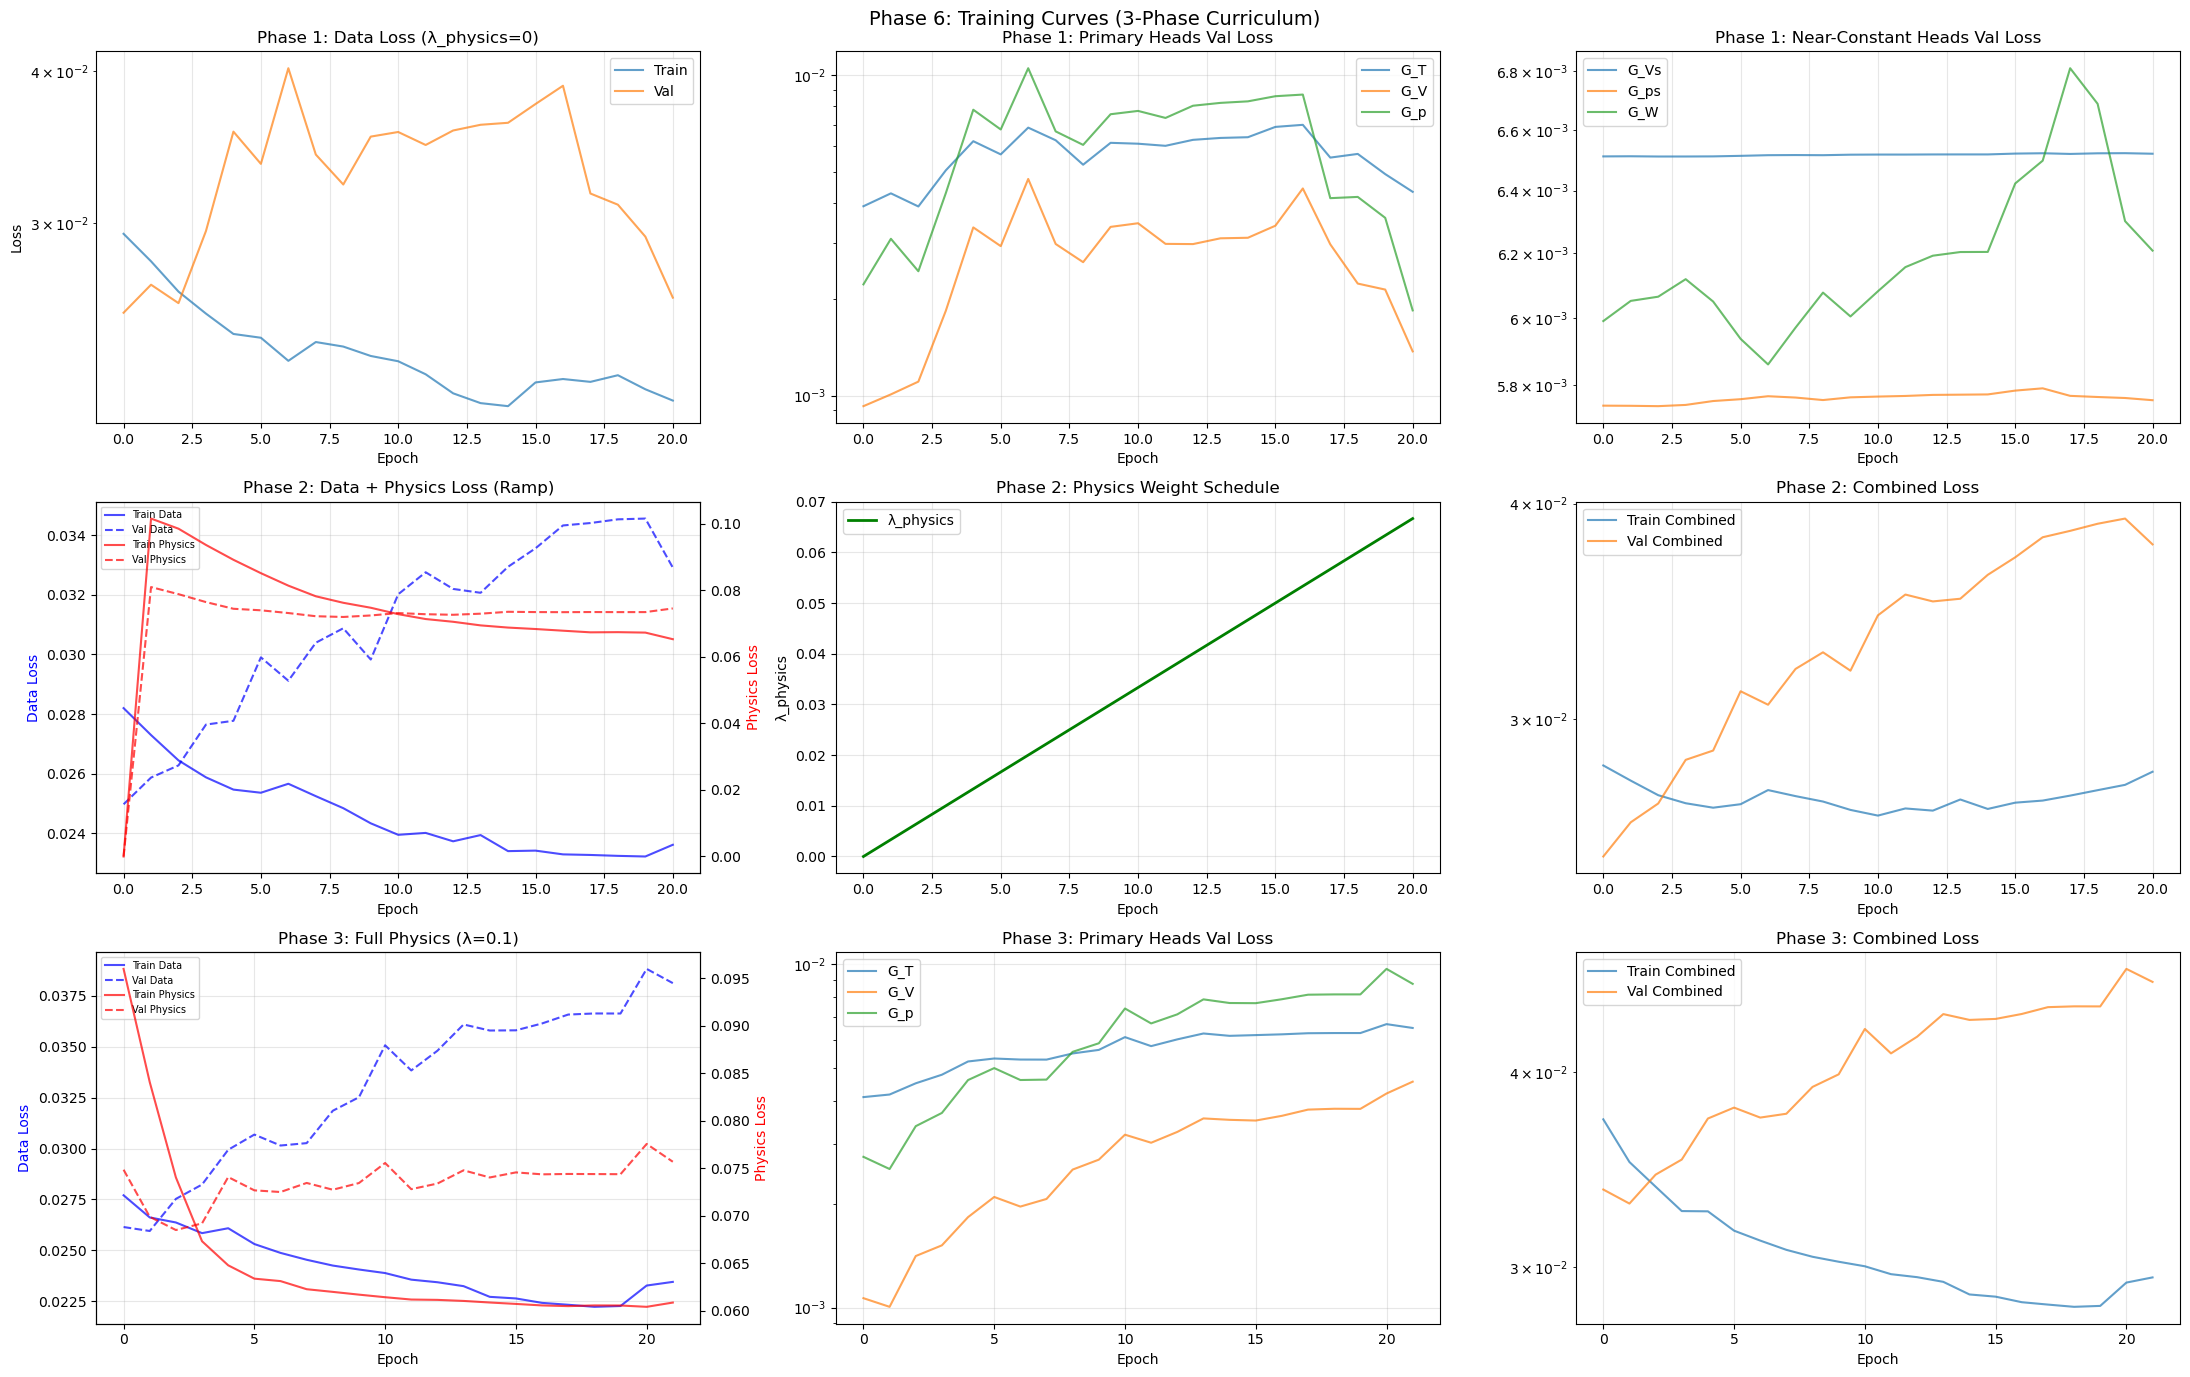

In [ ]:
#  Training Loss Curves — All 3 Phases

os.makedirs('phase_6_vis', exist_ok=True)

fig, axes = plt.subplots(3, 3, figsize=(22, 14))

# ── Phase 1 ──
axes[0, 0].plot(phase1_history['train_data'], label='Train', alpha=0.7)
axes[0, 0].plot(phase1_history['val_data'], label='Val', alpha=0.7)
axes[0, 0].set_title('Phase 1: Data Loss (λ_physics=0)')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].set_yscale('log'); axes[0, 0].grid(True, alpha=0.3)

for head in ['G_T', 'G_V', 'G_p']:
    axes[0, 1].plot(phase1_history[f'val_{head}'], label=head, alpha=0.7)
axes[0, 1].set_title('Phase 1: Primary Heads Val Loss')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend()
axes[0, 1].set_yscale('log'); axes[0, 1].grid(True, alpha=0.3)

for head in ['G_Vs', 'G_ps', 'G_W']:
    axes[0, 2].plot(phase1_history[f'val_{head}'], label=head, alpha=0.7)
axes[0, 2].set_title('Phase 1: Near-Constant Heads Val Loss')
axes[0, 2].set_xlabel('Epoch'); axes[0, 2].legend()
axes[0, 2].set_yscale('log'); axes[0, 2].grid(True, alpha=0.3)

# ── Phase 2 ──
ax = axes[1, 0]
ax.plot(phase2_history['train_data'], label='Train Data', alpha=0.7, color='blue')
ax.plot(phase2_history['val_data'], label='Val Data', alpha=0.7, color='blue', linestyle='--')
ax.set_ylabel('Data Loss', color='blue')
ax2 = ax.twinx()
ax2.plot(phase2_history['train_physics'], label='Train Physics', alpha=0.7, color='red')
ax2.plot(phase2_history['val_physics'], label='Val Physics', alpha=0.7, color='red', linestyle='--')
ax2.set_ylabel('Physics Loss', color='red')
ax.set_title('Phase 2: Data + Physics Loss (Ramp)')
ax.set_xlabel('Epoch')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(phase2_history['physics_weight'], 'g-', linewidth=2, label='λ_physics')
ax.set_title('Phase 2: Physics Weight Schedule')
ax.set_xlabel('Epoch'); ax.set_ylabel('λ_physics')
ax.legend(); ax.grid(True, alpha=0.3)

axes[1, 2].plot(phase2_history['train_combined'], label='Train Combined', alpha=0.7)
axes[1, 2].plot(phase2_history['val_combined'], label='Val Combined', alpha=0.7)
axes[1, 2].set_title('Phase 2: Combined Loss')
axes[1, 2].set_xlabel('Epoch'); axes[1, 2].legend()
axes[1, 2].set_yscale('log'); axes[1, 2].grid(True, alpha=0.3)

# ── Phase 3 ──
ax = axes[2, 0]
ax.plot(phase3_history['train_data'], label='Train Data', alpha=0.7, color='blue')
ax.plot(phase3_history['val_data'], label='Val Data', alpha=0.7, color='blue', linestyle='--')
ax.set_ylabel('Data Loss', color='blue')
ax2 = ax.twinx()
ax2.plot(phase3_history['train_physics'], label='Train Physics', alpha=0.7, color='red')
ax2.plot(phase3_history['val_physics'], label='Val Physics', alpha=0.7, color='red', linestyle='--')
ax2.set_ylabel('Physics Loss', color='red')
ax.set_title(f'Phase 3: Full Physics (λ={config.PHYSICS_WEIGHT_MAX})')
ax.set_xlabel('Epoch')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)
ax.grid(True, alpha=0.3)

for head in ['G_T', 'G_V', 'G_p']:
    axes[2, 1].plot(phase3_history[f'val_{head}'], label=head, alpha=0.7)
axes[2, 1].set_title('Phase 3: Primary Heads Val Loss')
axes[2, 1].set_xlabel('Epoch'); axes[2, 1].legend()
axes[2, 1].set_yscale('log'); axes[2, 1].grid(True, alpha=0.3)

axes[2, 2].plot(phase3_history['train_combined'], label='Train Combined', alpha=0.7)
axes[2, 2].plot(phase3_history['val_combined'], label='Val Combined', alpha=0.7)
axes[2, 2].set_title('Phase 3: Combined Loss')
axes[2, 2].set_xlabel('Epoch'); axes[2, 2].legend()
axes[2, 2].set_yscale('log'); axes[2, 2].grid(True, alpha=0.3)

plt.suptitle('Phase 6: Training Curves (3-Phase Curriculum)', fontsize=14)
plt.tight_layout()
plt.savefig('phase_6_vis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  Physics Constraint Evolution Plot

# Collect constraint names from phase 2 + phase 3 histories
constraint_keys_2 = [k for k in phase2_history if k.startswith('train_phys_')]
constraint_keys_3 = [k for k in phase3_history if k.startswith('train_phys_')]
all_constraint_keys = sorted(set(constraint_keys_2) | set(constraint_keys_3))

n_constraints = len(all_constraint_keys)
if n_constraints > 0:
    ncols = min(4, n_constraints)
    nrows = (n_constraints + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    if nrows * ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, key in enumerate(all_constraint_keys):
        ax = axes[idx]
        name = key.replace('train_phys_', '')
        
        # Phase 2 + Phase 3 concatenated
        p2 = phase2_history.get(key, [])
        p3 = phase3_history.get(key, [])
        epochs_p2 = list(range(config.PHASE1_EPOCHS, config.PHASE1_EPOCHS + len(p2)))
        epochs_p3 = list(range(config.PHASE1_EPOCHS + config.PHASE2_EPOCHS,
                                config.PHASE1_EPOCHS + config.PHASE2_EPOCHS + len(p3)))
        
        if p2:
            ax.plot(epochs_p2, p2, 'b-', alpha=0.7, label='Phase 2')
        if p3:
            ax.plot(epochs_p3, p3, 'r-', alpha=0.7, label='Phase 3')
        
        ax.axvline(config.PHASE1_EPOCHS + config.PHASE2_EPOCHS, color='gray',
                    linestyle='--', alpha=0.5, label='Phase 2→3')
        ax.set_title(name.replace('_', ' ').title(), fontsize=9)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)
    
    for idx in range(n_constraints, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Physics Constraint Evolution During Training', fontsize=13)
    plt.tight_layout()
    plt.savefig('phase_6_vis/physics_constraint_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No physics constraint data recorded.")

No physics constraint data recorded.


## Evaluation on Test Set

### Performance Metrics (from Chapter 3)

**Primary Accuracy Measures:** MAE, RMSE, R², Variance Ratio, Correlation Coefficient

**Delta Prediction Metrics:** Delta Std Ratio, Cumulative Drift Error

**Comparison Metrics:** Persistence R², Skill Score, Beats Persistence flag

**Per-Head Analysis:** Performance breakdown by decoder head group (G_T, G_V, G_p, G_Vs, G_ps, G_W)

**Physics Compliance:** Per-constraint violation rates on test set (unique to Phase 6)

**Computational Performance:** Training time per phase, total epochs, model parameters, inference time

In [ ]:
#  Collect Test Predictions

@torch.no_grad()
def collect_predictions(model, loader, config, normalizer, column_info, device):
    """Run model on test loader and collect predictions + targets in absolute space."""
    model.eval()
    all_preds, all_targets, all_last_dyn, all_future_dyn = [], [], [], []

    for batch in tqdm(loader, desc="Collecting predictions", leave=False):
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)

        output = model(u_hist, y_hist)
        predictions = output['predictions']  # (B, K, n_dynamic)

        all_preds.append(predictions.cpu().numpy())
        all_targets.append(batch['y_delta'].numpy())
        all_last_dyn.append(batch['last_dynamic'].numpy())
        all_future_dyn.append(batch['future_dynamic'].numpy())

    pred_norm = np.concatenate(all_preds)
    last_dyn = np.concatenate(all_last_dyn)
    future_dyn = np.concatenate(all_future_dyn)

    # Convert normalized deltas → absolute values
    dynamic_cols = column_info['dynamic_cols']
    pred_absolute = normalizer.inverse_delta(pred_norm, last_dyn, dynamic_cols)

    return {
        'pred_absolute': pred_absolute,
        'target_absolute': future_dyn,
        'pred_normalized': pred_norm,
        'target_normalized': np.concatenate(all_targets),
        'last_dynamic': last_dyn,
    }


print("Collecting test predictions...")
inference_start = time.time()
predictions_dict = collect_predictions(model, test_loader, config, normalizer, column_info, DEVICE)
inference_time = time.time() - inference_start
n_test_samples = predictions_dict['pred_absolute'].shape[0]

print(f"Predictions shape: {predictions_dict['pred_absolute'].shape}")
print(f"Inference time: {inference_time:.2f}s ({inference_time/n_test_samples*1000:.2f} ms/sample)")

Predictions shape: (174, 1, 2827)
Inference time: 1.45s (8.36 ms/sample)


In [ ]:
#  Compute Comprehensive Metrics (Chapter 3 Standard)

def compute_metrics(predictions_dict, column_info, config):
    """Compute per-output metrics matching Chapter 3 evaluation criteria."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_dyn = predictions_dict['last_dynamic']
    pred_norm = predictions_dict['pred_normalized']
    target_norm = predictions_dict['target_normalized']
    dynamic_cols = column_info['dynamic_cols']
    K = config.PREDICTION_STEPS

    # Build group lookup
    group_of_idx = {}
    for hname, indices in [
        ('G_T', column_info['temp_indices']),
        ('G_V', column_info['flow_indices']),
        ('G_p', column_info['pressure_indices']),
        ('G_Vs', column_info['flow_sec_indices']),
        ('G_ps', column_info['pressure_sec_indices']),
        ('G_W', column_info['power_indices']),
    ]:
        for idx in indices:
            group_of_idx[idx] = hname

    results = []
    for i, col in enumerate(dynamic_cols):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()

        # Primary metrics
        mae = np.mean(np.abs(p - t))
        rmse = np.sqrt(np.mean((p - t) ** 2))
        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        # Variance ratio
        var_pred = np.var(p)
        var_true = np.var(t)
        variance_ratio = var_pred / (var_true + 1e-10)

        # Correlation coefficient
        if np.std(p) > 1e-10 and np.std(t) > 1e-10:
            correlation = np.corrcoef(p, t)[0, 1]
        else:
            correlation = 0.0

        # Delta metrics
        pred_d = pred_norm[:, :, i].flatten()
        targ_d = target_norm[:, :, i].flatten()
        delta_std_ratio = np.std(pred_d) / (np.std(targ_d) + 1e-10)

        # Cumulative drift (only meaningful for K > 1)
        cumulative_drift = 0.0
        if K > 1:
            cumulative_drift = np.mean(np.abs(pred[:, -1, i] - target[:, -1, i])) - \
                               np.mean(np.abs(pred[:, 0, i] - target[:, 0, i]))

        # Persistence baseline
        last_val = last_dyn[:, i]
        persistence = np.repeat(last_val[:, np.newaxis], K, axis=1).flatten()
        ss_res_pers = np.sum((t - persistence) ** 2)
        r2_pers = 1 - ss_res_pers / (ss_tot + 1e-10)
        skill_score = (r2 - r2_pers) / (1 - r2_pers + 1e-10)

        # Per-step R²
        step_r2 = []
        for k in range(K):
            pk = pred[:, k, i]
            tk = target[:, k, i]
            ss_res_k = np.sum((tk - pk) ** 2)
            ss_tot_k = np.sum((tk - tk.mean()) ** 2)
            step_r2.append(1 - ss_res_k / (ss_tot_k + 1e-10))

        cdu_id = column_info['col_to_cdu'].get(col, 'Unknown')
        output_type = column_info['col_to_type'].get(col, 'Unknown')
        group = group_of_idx.get(i, 'Unknown')

        # Determine loop classification
        loop = 'primary'
        if group in ['G_Vs', 'G_ps', 'G_W']:
            loop = 'secondary'
        elif output_type in ['T_sec_s_C', 'T_sec_r_C']:
            loop = 'secondary'

        results.append({
            'Output': col,
            'CDU': cdu_id,
            'Output_Type': output_type,
            'Group': group,
            'Loop': loop,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Variance_Ratio': variance_ratio,
            'Correlation': correlation,
            'Delta_Std_Ratio': delta_std_ratio,
            'Cumulative_Drift': cumulative_drift,
            'Persistence_R2': r2_pers,
            'Beats_Persistence': r2 > r2_pers,
            'Skill_Score': skill_score,
            **{f'R2_step{k+1}': step_r2[k] for k in range(K)},
        })

    return pd.DataFrame(results)


metrics_df = compute_metrics(predictions_dict, column_info, config)
print(f"Metrics computed for {len(metrics_df)} outputs.")

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
Exception ignored in: <function _ConnectionBase.__del__ at 0x7fe595159080>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    reader_close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    self._close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "

Metrics computed for 2827 outputs.


In [ ]:
#  Results Summary — Overall, Per-Group, Per-Output-Type

ALL_HEAD_NAMES = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']

print("\n" + "=" * 70)
print("RESULTS SUMMARY — Phase 6: Physics-Informed Federated DeepM&Mnet")
print("=" * 70)

# Overall
print(f"\n--- All {len(metrics_df)} Outputs ---")
print(f"  Mean R²:           {metrics_df['R2'].mean():.4f}")
print(f"  Median R²:         {metrics_df['R2'].median():.4f}")
print(f"  Min R²:            {metrics_df['R2'].min():.4f}")
print(f"  Max R²:            {metrics_df['R2'].max():.4f}")
print(f"  Std R²:            {metrics_df['R2'].std():.4f}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)} "
      f"({metrics_df['Beats_Persistence'].mean():.1%})")
print(f"  Mean Skill Score:  {metrics_df['Skill_Score'].mean():.4f}")

# Per-group summary
print(f"\n--- Per Decoder Head Group ---")
for group in ALL_HEAD_NAMES:
    grp = metrics_df[metrics_df['Group'] == group]
    if len(grp) == 0:
        continue
    head_type = column_info['head_groups'][group]['type']
    print(f"\n  {group} ({head_type}, {len(grp)} outputs):")
    print(f"    Mean R²:         {grp['R2'].mean():.4f}")
    print(f"    Median R²:       {grp['R2'].median():.4f}")
    print(f"    Variance Ratio:  {grp['Variance_Ratio'].mean():.4f}")
    print(f"    Mean Correlation:{grp['Correlation'].mean():.4f}")
    print(f"    Beats Persist:   {grp['Beats_Persistence'].sum()}/{len(grp)} "
          f"({grp['Beats_Persistence'].mean():.1%})")

# Per output-type summary
print(f"\n--- Per Output Type ---")
output_types = config.ALL_DYNAMIC_OUTPUTS
type_summary = metrics_df.groupby('Output_Type').agg({
    'R2': ['mean', 'median', 'min', 'max'],
    'RMSE': 'mean',
    'MAE': 'mean',
    'Variance_Ratio': 'mean',
    'Correlation': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(type_summary.to_string())

# R² distribution
print(f"\n--- R² Distribution ---")
for threshold, label in [(0.99, '≥ 0.99'), (0.95, '≥ 0.95'), (0.90, '≥ 0.90'),
                          (0.80, '≥ 0.80'), (0.50, '≥ 0.50'), (0.0, '≥ 0.00')]:
    count = (metrics_df['R2'] >= threshold).sum()
    print(f"  R² {label}: {count}/{len(metrics_df)} ({count/len(metrics_df):.1%})")
count_neg = (metrics_df['R2'] < 0).sum()
print(f"  R² < 0.00: {count_neg}/{len(metrics_df)} ({count_neg/len(metrics_df):.1%})")

# Computational summary
print(f"\n--- Computational Performance ---")
print(f"  Model Parameters:     {total_params:,}")
print(f"  Phase 1 Epochs:       {phase1_epochs}")
print(f"  Phase 2 Epochs:       {phase2_epochs}")
print(f"  Phase 3 Epochs:       {phase3_epochs}")
print(f"  Total Epochs:         {total_epochs}")
print(f"  Phase 1 Time:         {phase1_time:.1f}s ({phase1_time/60:.1f} min)")
print(f"  Phase 2 Time:         {phase2_time:.1f}s ({phase2_time/60:.1f} min)")
print(f"  Phase 3 Time:         {phase3_time:.1f}s ({phase3_time/60:.1f} min)")
print(f"  Total Training Time:  {total_train_time:.1f}s ({total_train_time/60:.1f} min)")
print(f"  Inference Time:       {inference_time:.2f}s")
print(f"  Per sample:           {inference_time/n_test_samples*1000:.2f} ms")


RESULTS SUMMARY — Phase 6: Physics-Informed Federated DeepM&Mnet

--- All 2827 Outputs ---
  Mean R²:           0.9631
  Median R²:         0.9923
  Min R²:            0.2286
  Max R²:            0.9996
  Std R²:            0.0720
  Beats Persistence: 990/2827 (35.0%)
  Mean Skill Score:  -0.0430

--- Per Decoder Head Group ---

  G_T (standard, 1028 outputs):
    Mean R²:         0.9921
    Median R²:       0.9939
    Variance Ratio:  0.9903
    Mean Correlation:0.9963
    Beats Persist:   385/1028 (37.5%)

  G_V (standard, 257 outputs):
    Mean R²:         0.9810
    Median R²:       0.9811
    Variance Ratio:  0.9678
    Mean Correlation:0.9905
    Beats Persist:   220/257 (85.6%)

  G_p (standard, 514 outputs):
    Mean R²:         0.9930
    Median R²:       0.9930
    Variance Ratio:  0.9644
    Mean Correlation:0.9967
    Beats Persist:   34/514 (6.6%)

  G_Vs (skip, 257 outputs):
    Mean R²:         0.8124
    Median R²:       0.8502
    Variance Ratio:  1.0033
    Mean Corr

## Evaluation Metric Visualizations

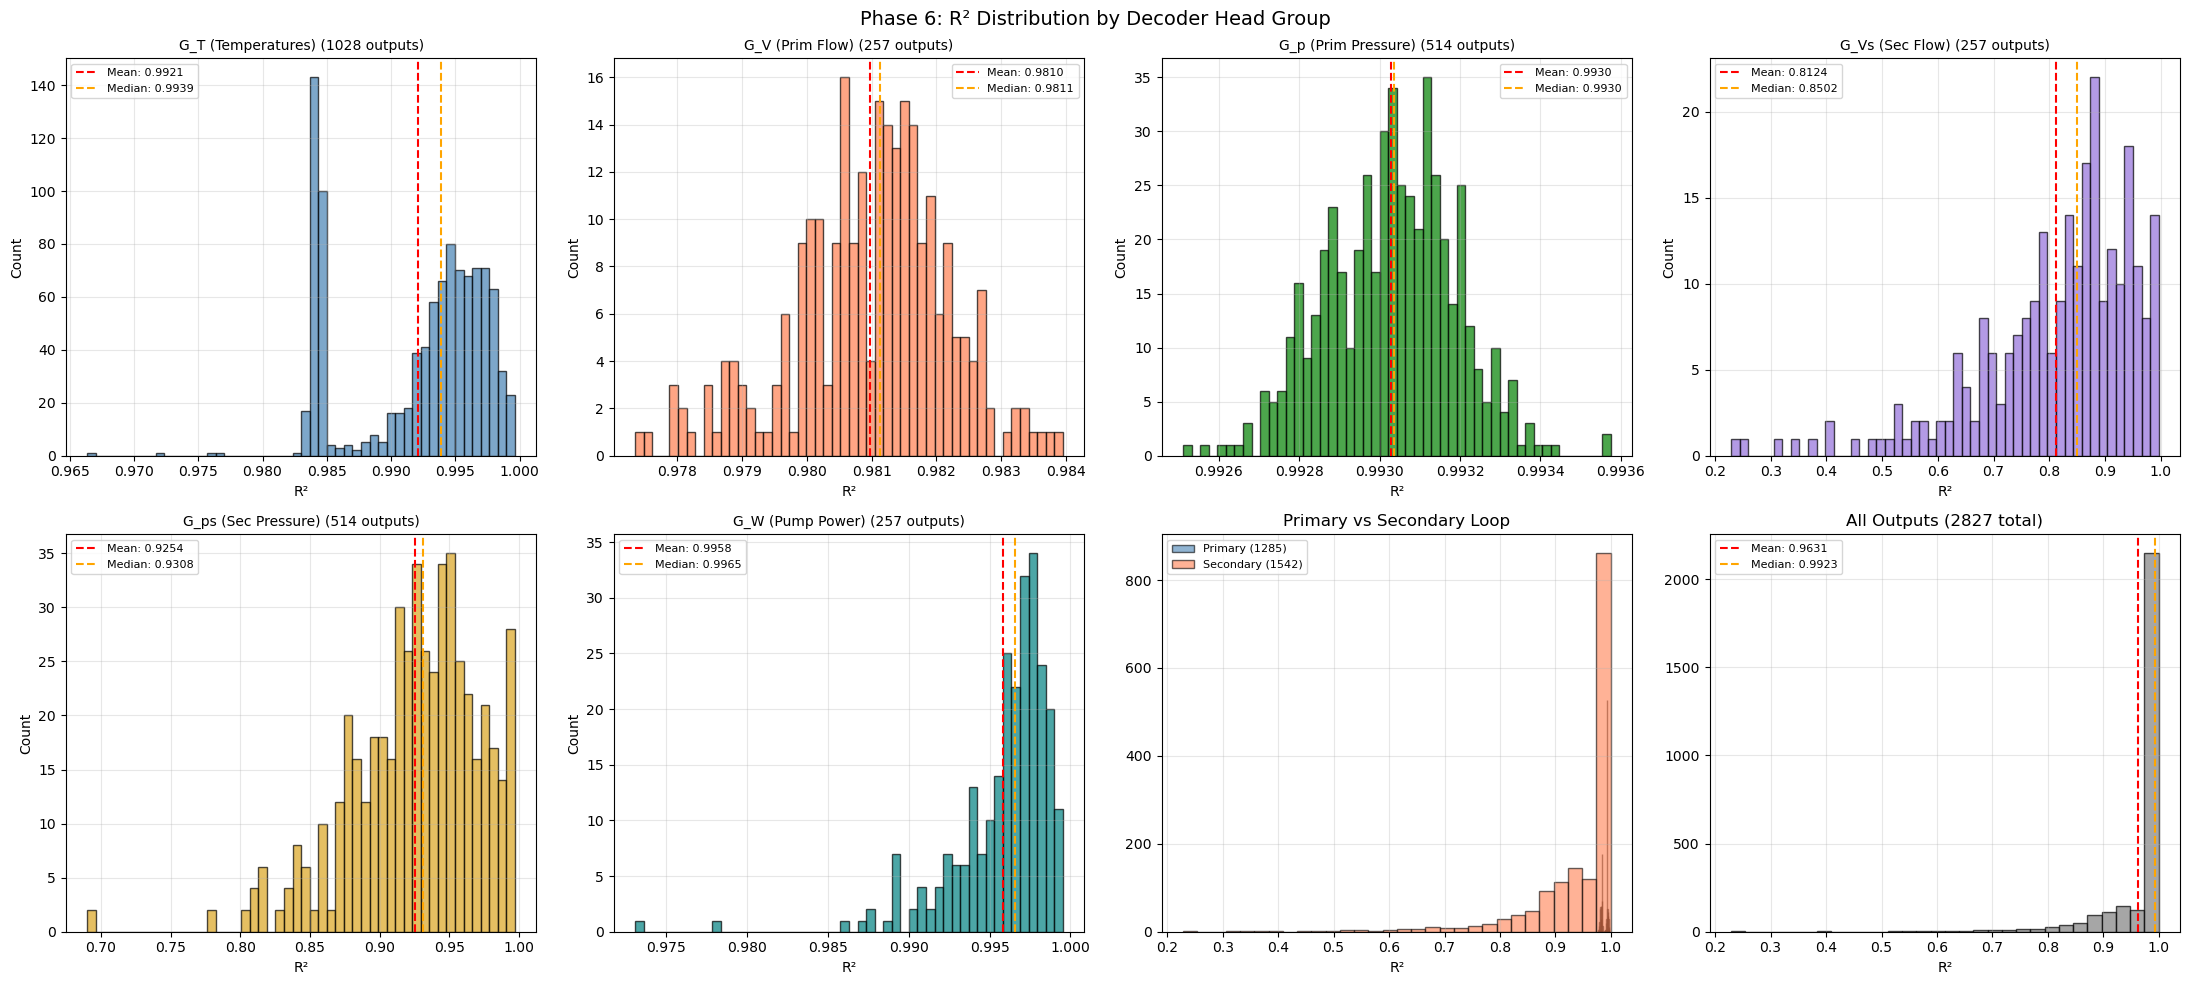

In [ ]:
#  Visualization 1 — R² Distribution by Decoder Head Group

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

group_names = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']
group_labels = ['G_T (Temperatures)', 'G_V (Prim Flow)', 'G_p (Prim Pressure)',
                'G_Vs (Sec Flow)', 'G_ps (Sec Pressure)', 'G_W (Pump Power)']
colors = ['steelblue', 'coral', 'green', 'mediumpurple', 'goldenrod', 'teal']
group_colors_map = dict(zip(group_names, colors))

for idx, (group, label, color) in enumerate(zip(group_names, group_labels, colors)):
    ax = axes[idx]
    group_data = metrics_df[metrics_df['Group'] == group]['R2']
    if len(group_data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(group_data, bins=min(50, len(group_data)), alpha=0.7,
            edgecolor='black', color=color)
    ax.axvline(group_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {group_data.mean():.4f}')
    ax.axvline(group_data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {group_data.median():.4f}')
    ax.set_title(f'{label} ({len(group_data)} outputs)', fontsize=10)
    ax.set_xlabel('R²'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Primary vs Secondary
ax = axes[6]
prim = metrics_df[metrics_df['Loop'] == 'primary']['R2']
sec = metrics_df[metrics_df['Loop'] == 'secondary']['R2']
ax.hist(prim, bins=30, alpha=0.6, label=f'Primary ({len(prim)})', color='steelblue', edgecolor='black')
ax.hist(sec, bins=30, alpha=0.6, label=f'Secondary ({len(sec)})', color='coral', edgecolor='black')
ax.set_title('Primary vs Secondary Loop'); ax.set_xlabel('R²')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Overall
ax = axes[7]
ax.hist(metrics_df['R2'], bins=30, alpha=0.7, edgecolor='black', color='gray')
ax.axvline(metrics_df['R2'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {metrics_df["R2"].mean():.4f}')
ax.axvline(metrics_df['R2'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {metrics_df["R2"].median():.4f}')
ax.set_title(f'All Outputs ({len(metrics_df)} total)'); ax.set_xlabel('R²')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Phase 6: R² Distribution by Decoder Head Group', fontsize=14)
plt.tight_layout()
plt.savefig('phase_6_vis/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

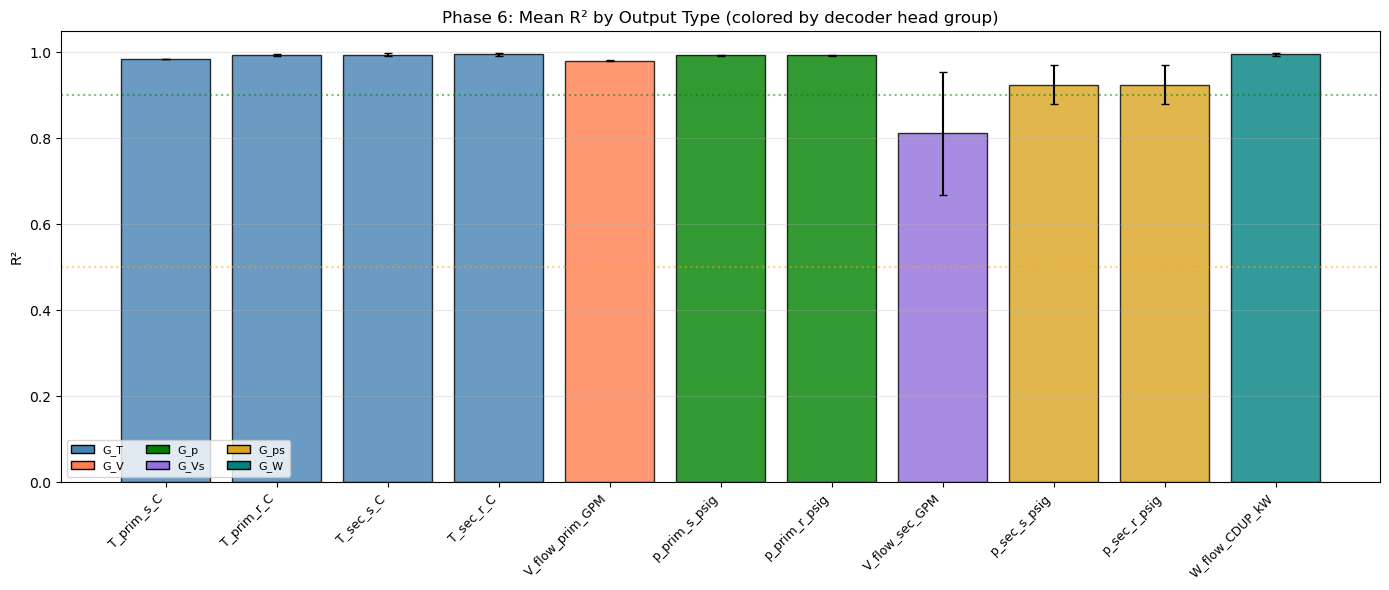

In [ ]:
#  Visualization 2 — Per-Output-Type R² Bar Chart

fig, ax = plt.subplots(figsize=(14, 6))
for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_r2 = subset['R2'].mean()
    std_r2 = subset['R2'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax.bar(i, mean_r2, yerr=std_r2, color=color, edgecolor='black', alpha=0.8, capsize=3)

ax.set_xticks(range(len(output_types)))
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Phase 6: Mean R² by Output Type (colored by decoder head group)')
ax.axhline(y=0.9, color='green', linestyle=':', alpha=0.5, label='R²=0.9')
ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='R²=0.5')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=g)
                   for g, c in group_colors_map.items()]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, ncol=3)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_6_vis/r2_by_output_type.png', dpi=150, bbox_inches='tight')
plt.show()

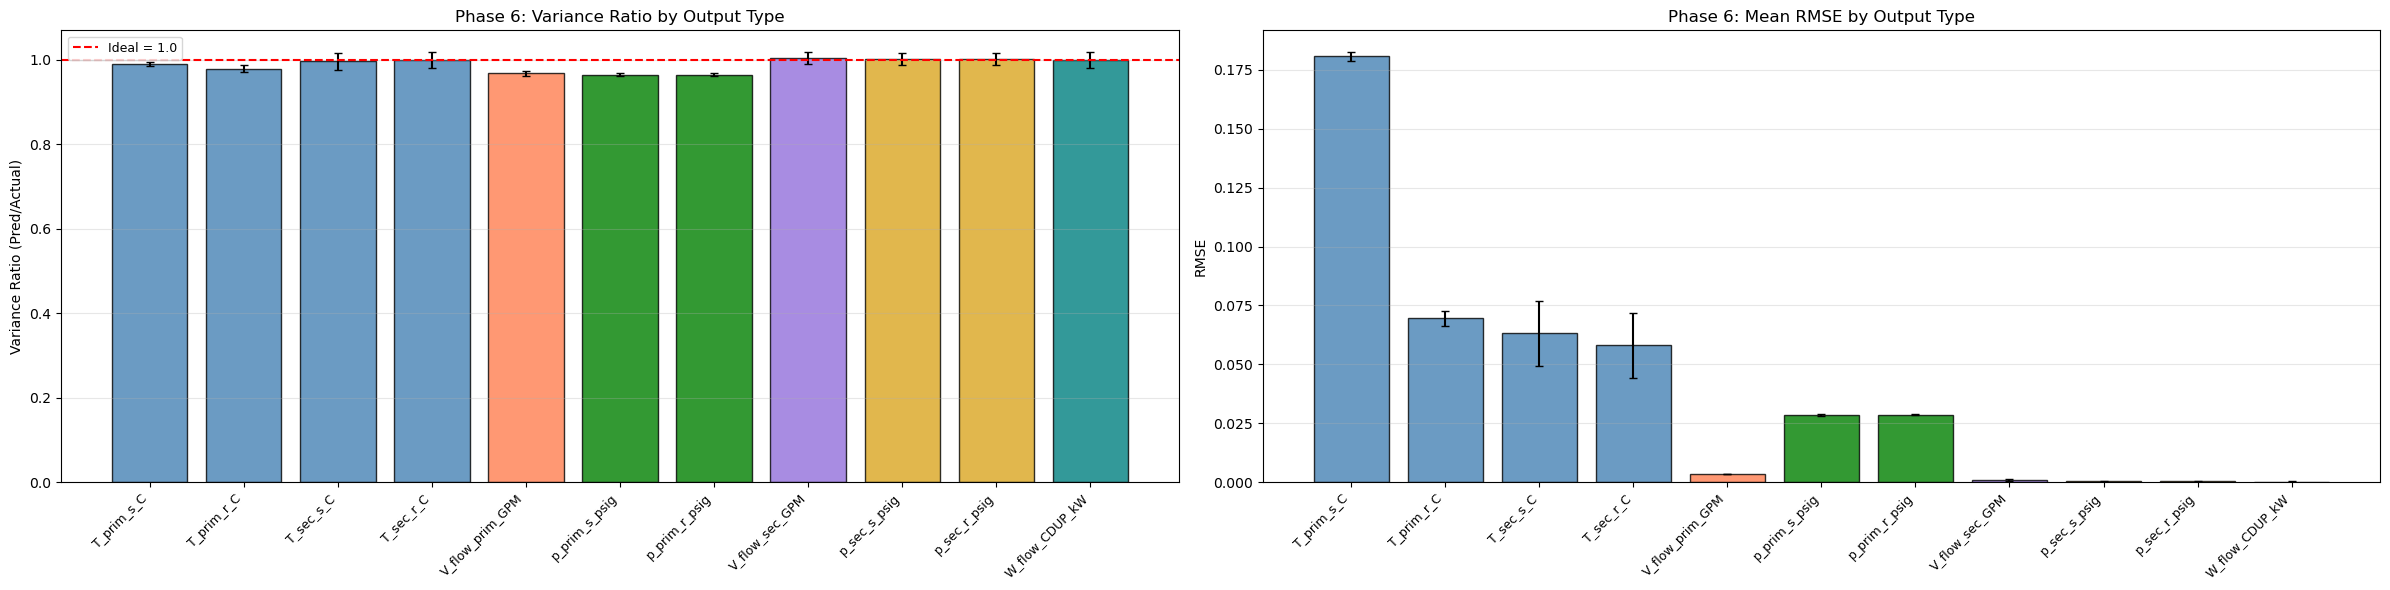

In [ ]:
#  Visualization 3 — Variance Ratio + RMSE by Output Type

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))

# Variance Ratio
for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_vr = subset['Variance_Ratio'].mean()
    std_vr = subset['Variance_Ratio'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax1.bar(i, mean_vr, yerr=std_vr, color=color, edgecolor='black', alpha=0.8, capsize=3)

ax1.set_xticks(range(len(output_types)))
ax1.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Variance Ratio (Pred/Actual)')
ax1.set_title('Phase 6: Variance Ratio by Output Type')
ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Ideal = 1.0')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3, axis='y')

# RMSE
for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_rmse = subset['RMSE'].mean()
    std_rmse = subset['RMSE'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax2.bar(i, mean_rmse, yerr=std_rmse, color=color, edgecolor='black', alpha=0.8, capsize=3)

ax2.set_xticks(range(len(output_types)))
ax2.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('RMSE')
ax2.set_title('Phase 6: Mean RMSE by Output Type')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase_6_vis/variance_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

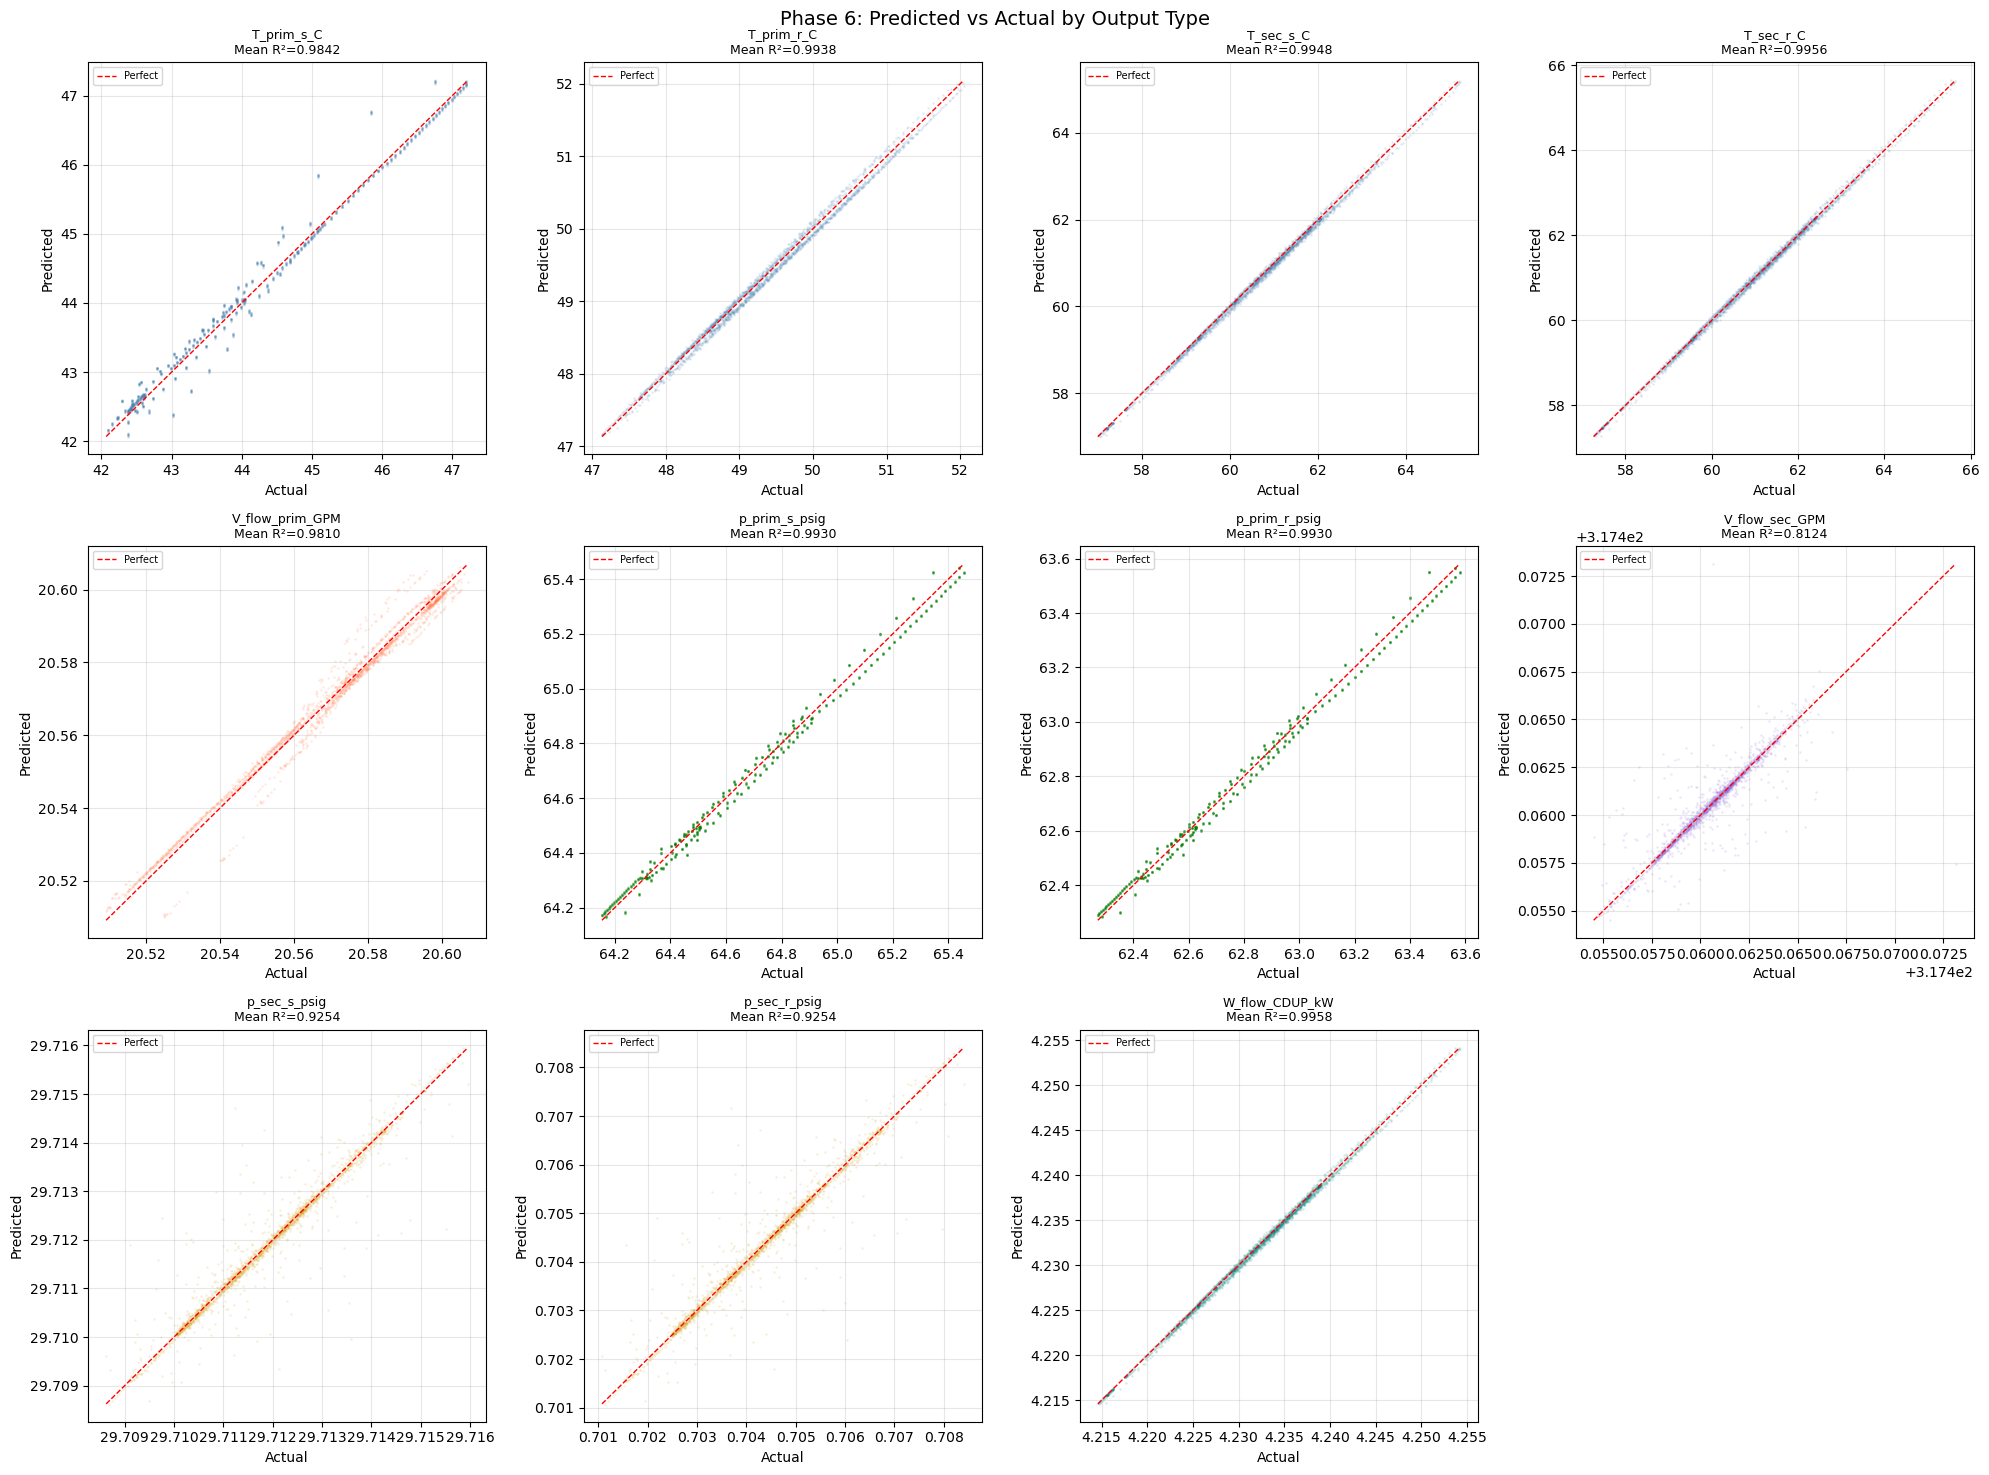

In [ ]:
#  Visualization 4 — Scatter Plots (Predicted vs Actual) per Output Type

pred_abs = predictions_dict['pred_absolute']
tgt_abs = predictions_dict['target_absolute']

n_types = len(output_types)
ncols = 4
nrows = (n_types + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for idx, otype in enumerate(output_types):
    ax = axes[idx]
    type_cols = [i for i, col in enumerate(column_info['dynamic_cols']) if otype in col]
    if not type_cols:
        ax.set_visible(False); continue

    sample_cols = type_cols[::max(1, len(type_cols)//10)]
    pred_vals = pred_abs[:, :, sample_cols].flatten()
    tgt_vals = tgt_abs[:, :, sample_cols].flatten()

    ax.scatter(tgt_vals, pred_vals, alpha=0.1, s=1, color=group_colors_map.get(
        metrics_df[metrics_df['Output_Type'] == otype]['Group'].iloc[0], 'gray'))
    lims = [min(tgt_vals.min(), pred_vals.min()), max(tgt_vals.max(), pred_vals.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')

    subset = metrics_df[metrics_df['Output_Type'] == otype]
    ax.set_title(f'{otype}\nMean R²={subset["R2"].mean():.4f}', fontsize=9)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 6: Predicted vs Actual by Output Type', fontsize=14)
plt.tight_layout()
plt.savefig('phase_6_vis/scatter_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

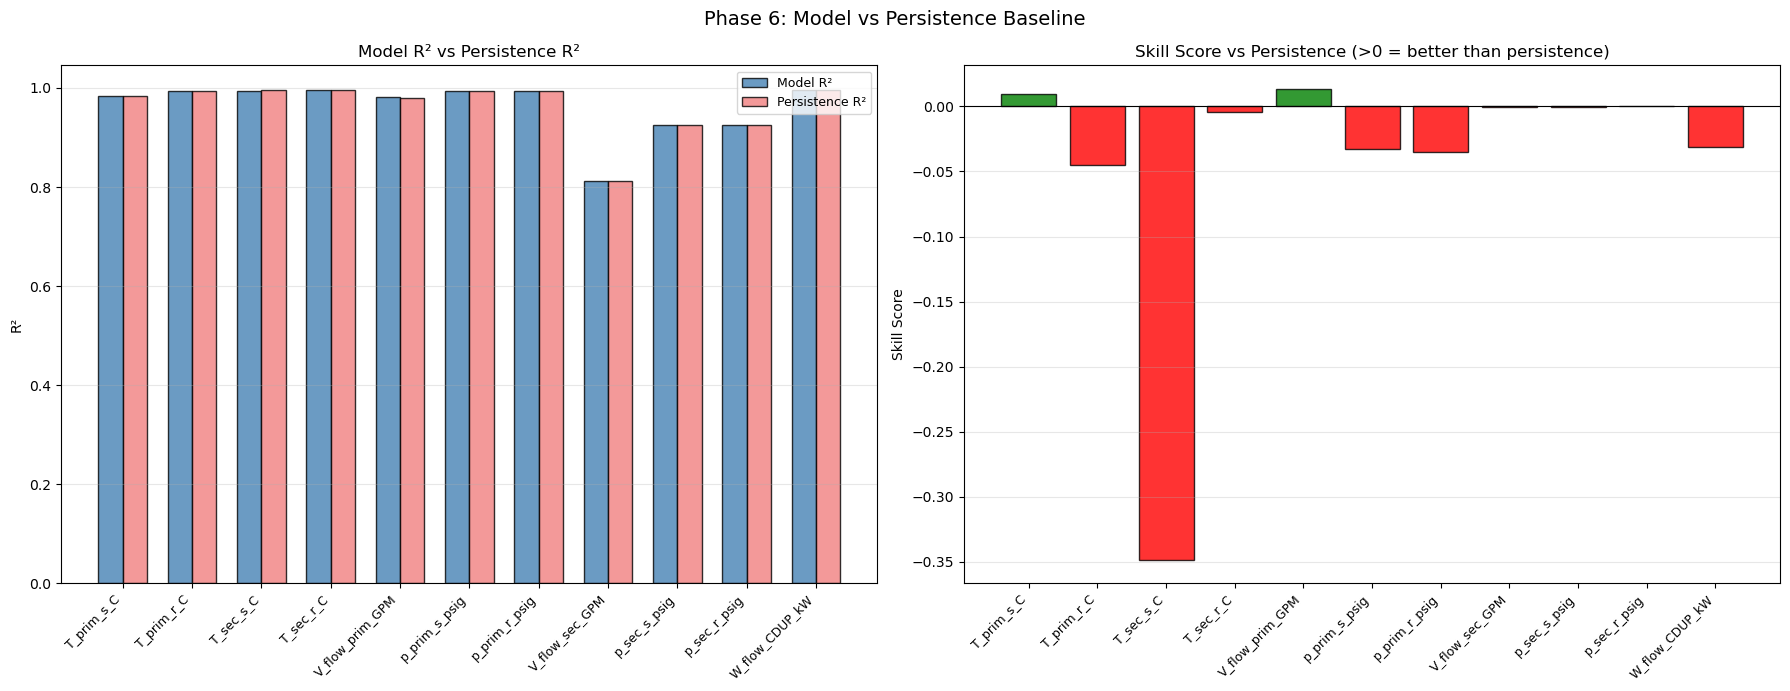

In [ ]:
#  Visualization 5 — Model vs Persistence (R² and Skill Score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

x = np.arange(len(output_types))
width = 0.35

model_r2 = [metrics_df[metrics_df['Output_Type'] == ot]['R2'].mean() for ot in output_types]
pers_r2 = [metrics_df[metrics_df['Output_Type'] == ot]['Persistence_R2'].mean() for ot in output_types]

bars1 = ax1.bar(x - width/2, model_r2, width, label='Model R²', color='steelblue',
                edgecolor='black', alpha=0.8)
bars2 = ax1.bar(x + width/2, pers_r2, width, label='Persistence R²', color='lightcoral',
                edgecolor='black', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('R²')
ax1.set_title('Model R² vs Persistence R²')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3, axis='y')

skill_scores = [metrics_df[metrics_df['Output_Type'] == ot]['Skill_Score'].mean()
                for ot in output_types]
colors_skill = ['green' if s > 0 else 'red' for s in skill_scores]
ax2.bar(x, skill_scores, color=colors_skill, edgecolor='black', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Skill Score')
ax2.set_title('Skill Score vs Persistence (>0 = better than persistence)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 6: Model vs Persistence Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('phase_6_vis/model_vs_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

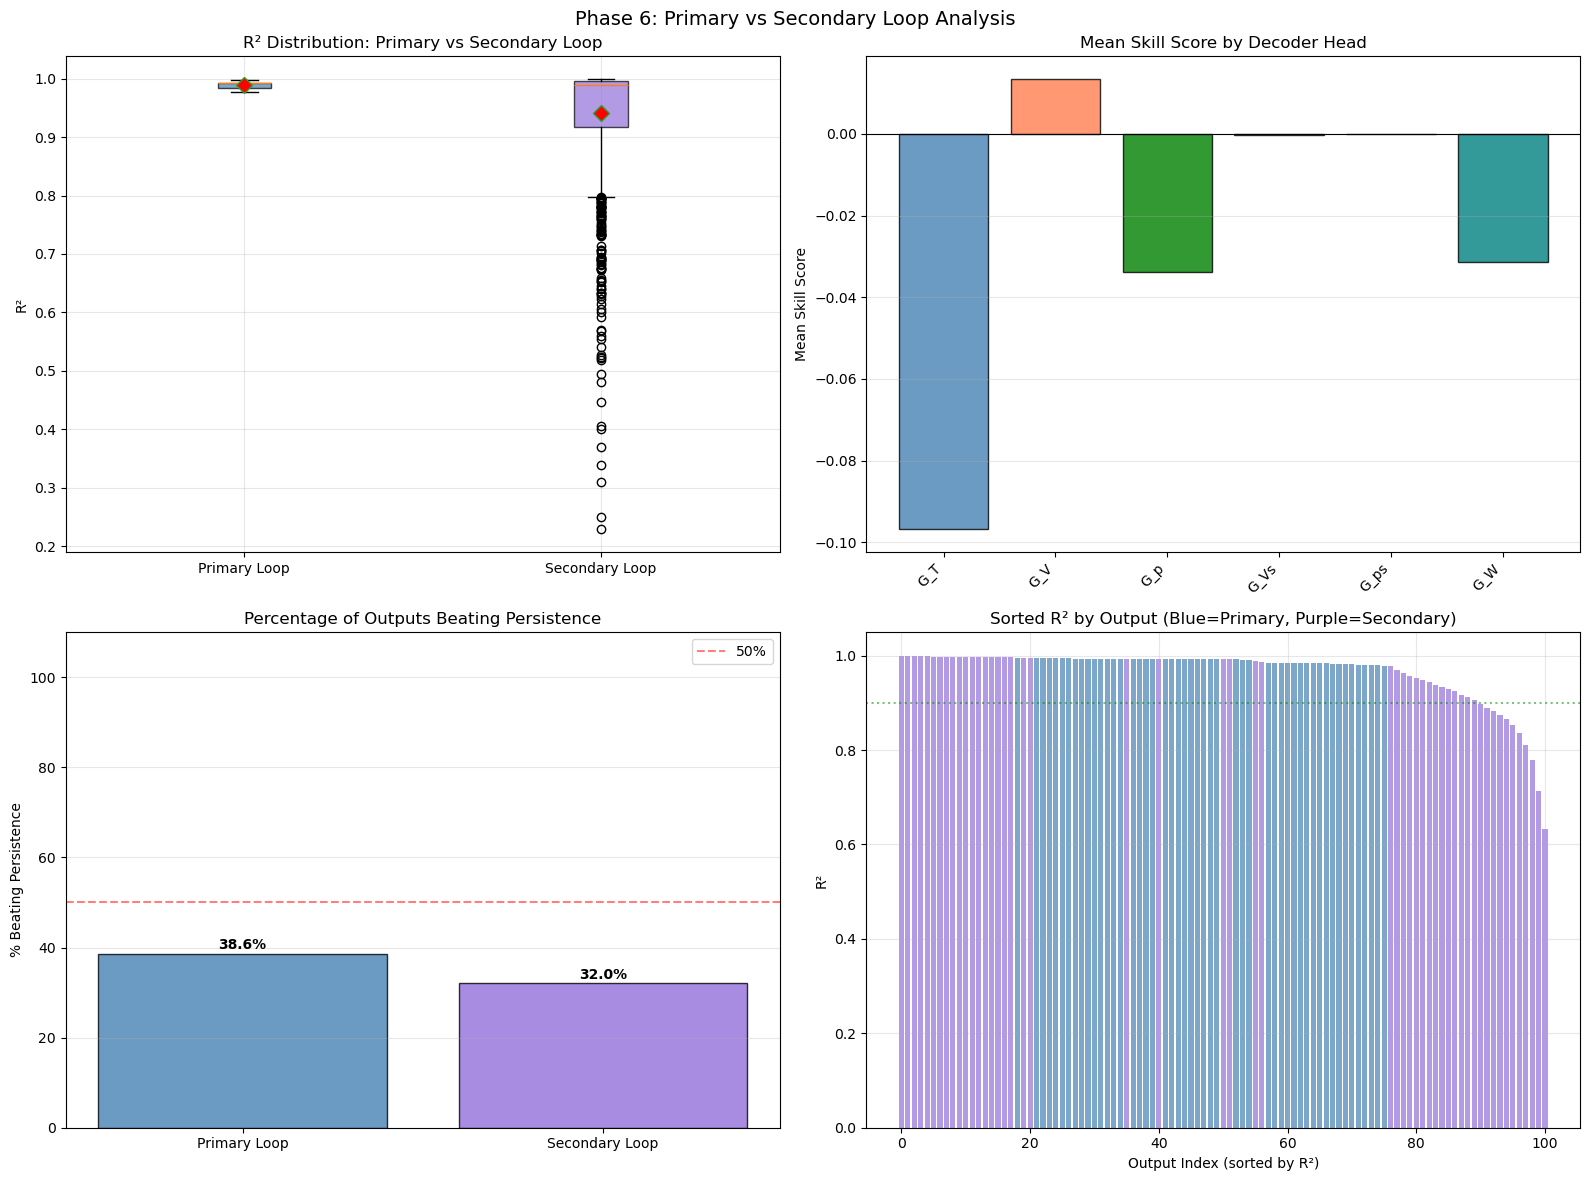

In [ ]:
#  Visualization 6 — Primary vs Secondary Loop Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

primary_df = metrics_df[metrics_df['Loop'] == 'primary']
secondary_df = metrics_df[metrics_df['Loop'] == 'secondary']

# (a) R² Boxplots by Loop
ax = axes[0, 0]
data_box = [primary_df['R2'].values, secondary_df['R2'].values]
bp = ax.boxplot(data_box, labels=['Primary Loop', 'Secondary Loop'],
                patch_artist=True, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 8})
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('mediumpurple'); bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('R²'); ax.set_title('R² Distribution: Primary vs Secondary Loop')
ax.grid(True, alpha=0.3)

# (b) Mean Skill Score by Group
ax = axes[0, 1]
skill_by_group = [metrics_df[metrics_df['Group'] == g]['Skill_Score'].mean()
                  for g in ALL_HEAD_NAMES]
colors_bar = [group_colors_map[g] for g in ALL_HEAD_NAMES]
ax.bar(range(len(ALL_HEAD_NAMES)), skill_by_group, color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(ALL_HEAD_NAMES)))
ax.set_xticklabels(ALL_HEAD_NAMES, rotation=45, ha='right')
ax.set_ylabel('Mean Skill Score'); ax.set_title('Mean Skill Score by Decoder Head')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')

# (c) Beats Persistence %
ax = axes[1, 0]
beats_prim = primary_df['Beats_Persistence'].mean() * 100
beats_sec = secondary_df['Beats_Persistence'].mean() * 100
ax.bar(['Primary Loop', 'Secondary Loop'], [beats_prim, beats_sec],
       color=['steelblue', 'mediumpurple'], edgecolor='black', alpha=0.8)
ax.set_ylabel('% Beating Persistence'); ax.set_title('Percentage of Outputs Beating Persistence')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
for i, v in enumerate([beats_prim, beats_sec]):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 110); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# (d) Sorted R² by Output
ax = axes[1, 1]
sorted_df = metrics_df.sort_values('R2', ascending=False)
sample_step = max(1, len(sorted_df) // 100)
sampled = sorted_df.iloc[::sample_step]
colors_sorted = ['steelblue' if l == 'primary' else 'mediumpurple' for l in sampled['Loop']]
ax.bar(range(len(sampled)), sampled['R2'].values, color=colors_sorted, alpha=0.7)
ax.set_xlabel('Output Index (sorted by R²)'); ax.set_ylabel('R²')
ax.set_title('Sorted R² by Output (Blue=Primary, Purple=Secondary)')
ax.axhline(y=0.9, color='green', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 6: Primary vs Secondary Loop Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('phase_6_vis/loop_dichotomy.png', dpi=150, bbox_inches='tight')
plt.show()

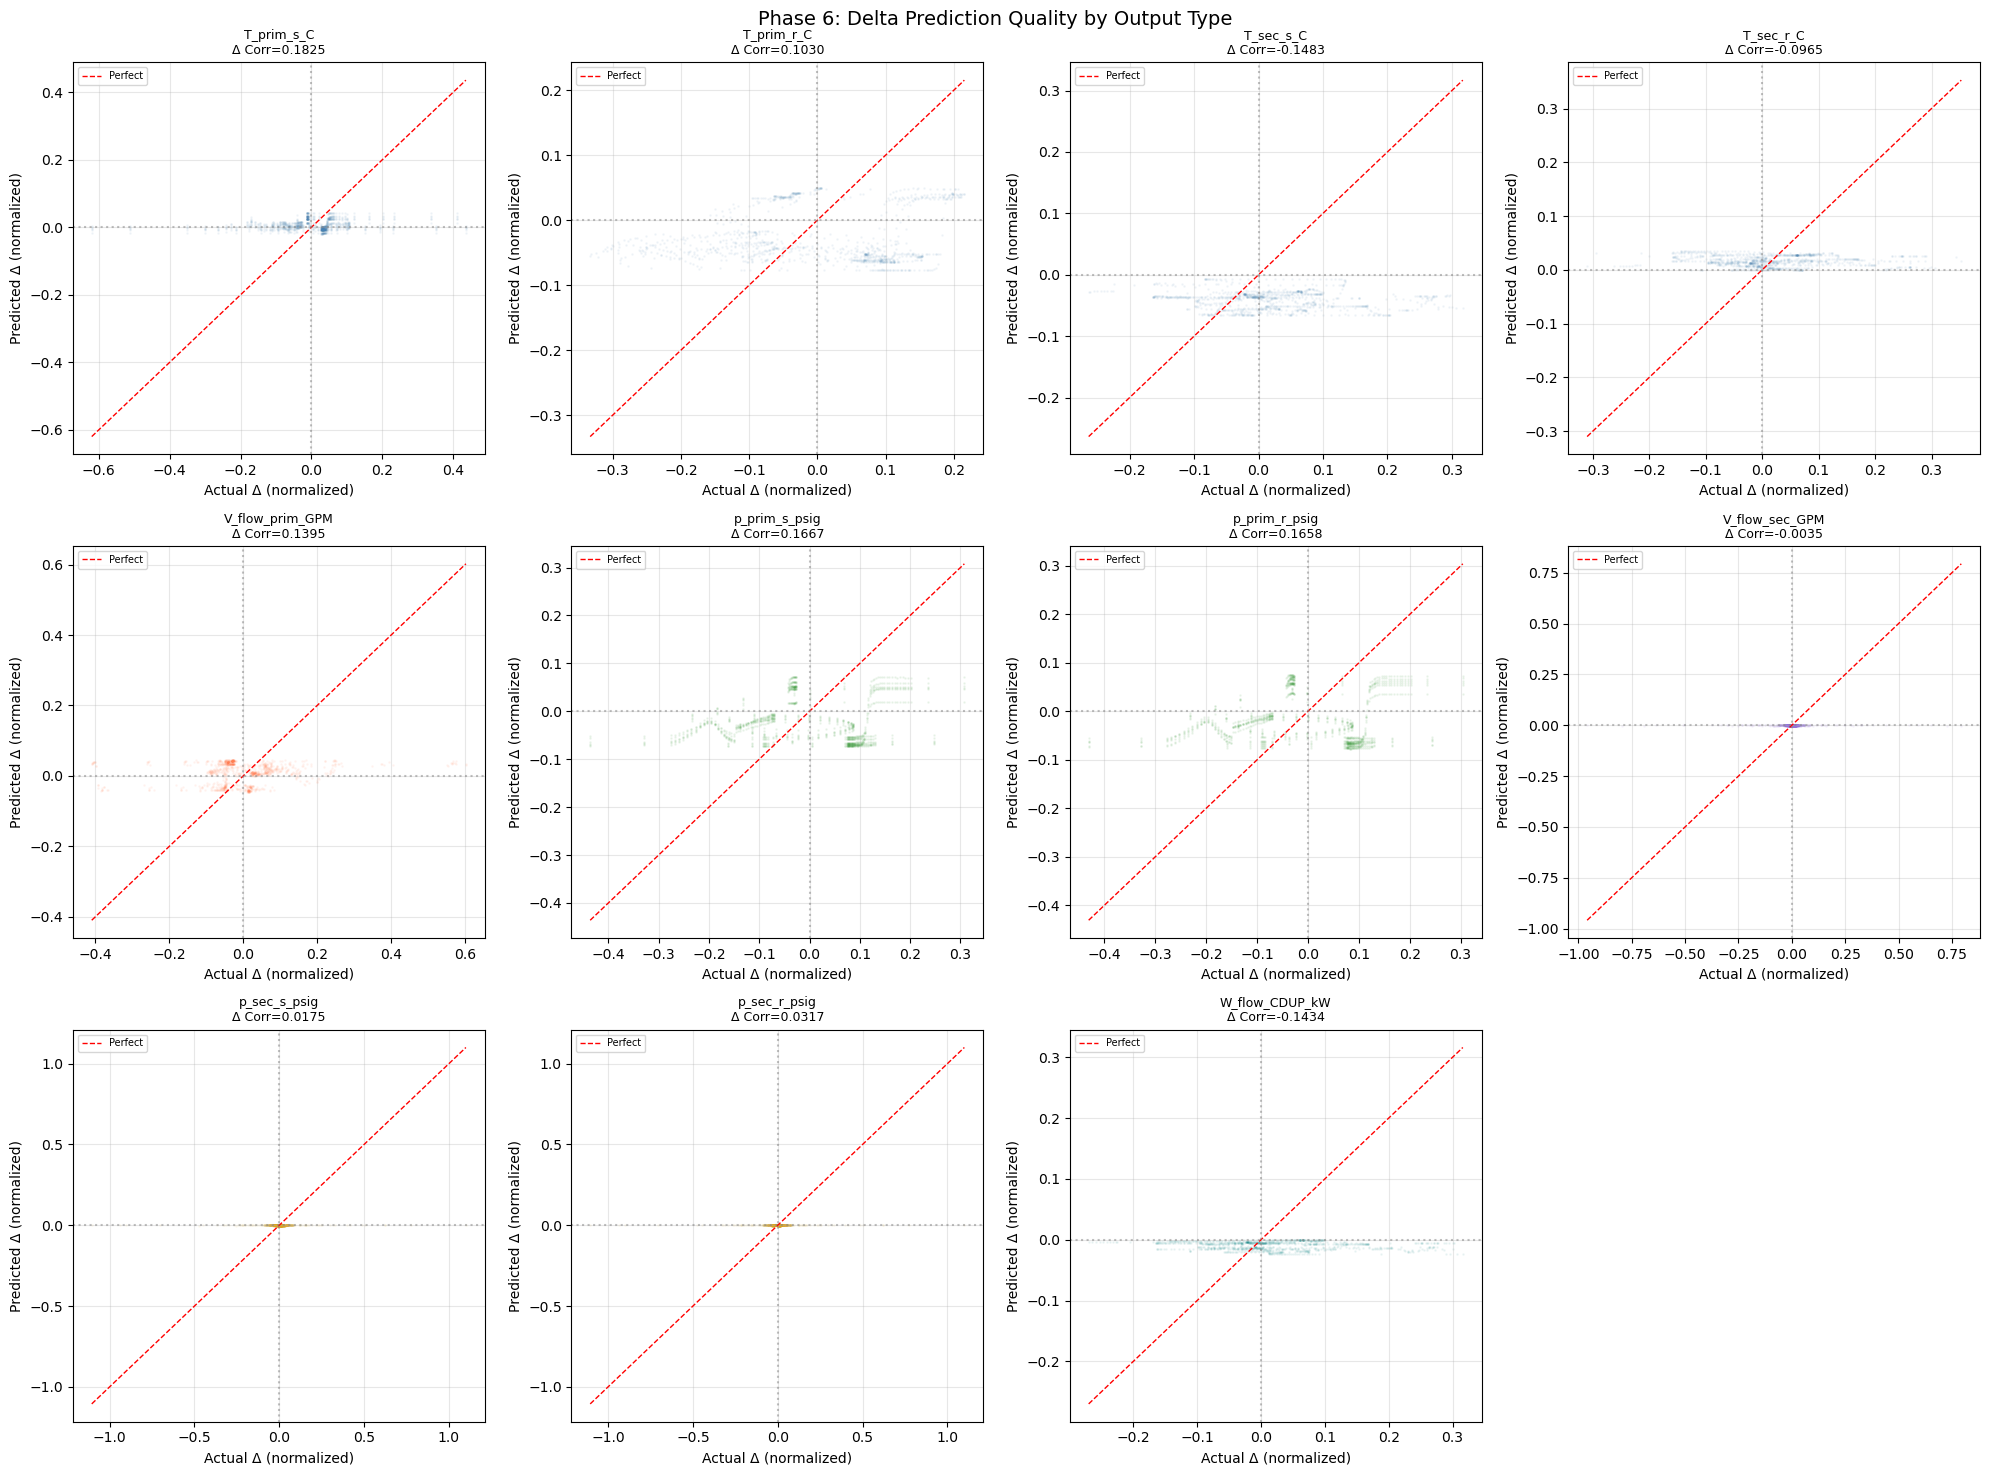

In [ ]:
#  Visualization 7 — Delta Prediction Quality

pred_norm = predictions_dict['pred_normalized']
tgt_norm = predictions_dict['target_normalized']

ncols = 4
nrows = (n_types + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for idx, otype in enumerate(output_types):
    ax = axes[idx]
    type_cols = [i for i, col in enumerate(column_info['dynamic_cols']) if otype in col]
    if not type_cols:
        ax.set_visible(False); continue

    sample_cols = type_cols[::max(1, len(type_cols)//5)]
    pred_deltas = pred_norm[:, :, sample_cols].flatten()
    tgt_deltas = tgt_norm[:, :, sample_cols].flatten()

    ax.scatter(tgt_deltas, pred_deltas, alpha=0.05, s=1,
               color=group_colors_map.get(
                   metrics_df[metrics_df['Output_Type'] == otype]['Group'].iloc[0], 'gray'))
    lims = [min(tgt_deltas.min(), pred_deltas.min()),
            max(tgt_deltas.max(), pred_deltas.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

    corr = np.corrcoef(tgt_deltas, pred_deltas)[0, 1] if len(tgt_deltas) > 1 else 0
    ax.set_title(f'{otype}\n\u0394 Corr={corr:.4f}', fontsize=9)
    ax.set_xlabel('Actual \u0394 (normalized)'); ax.set_ylabel('Predicted \u0394 (normalized)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 6: Delta Prediction Quality by Output Type', fontsize=14)
plt.tight_layout()
plt.savefig('phase_6_vis/delta_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Time-Series Predictions (300-second sample)

Visualize model predictions vs actual values over consecutive prediction windows for each output type. Includes persistence baseline for comparison.

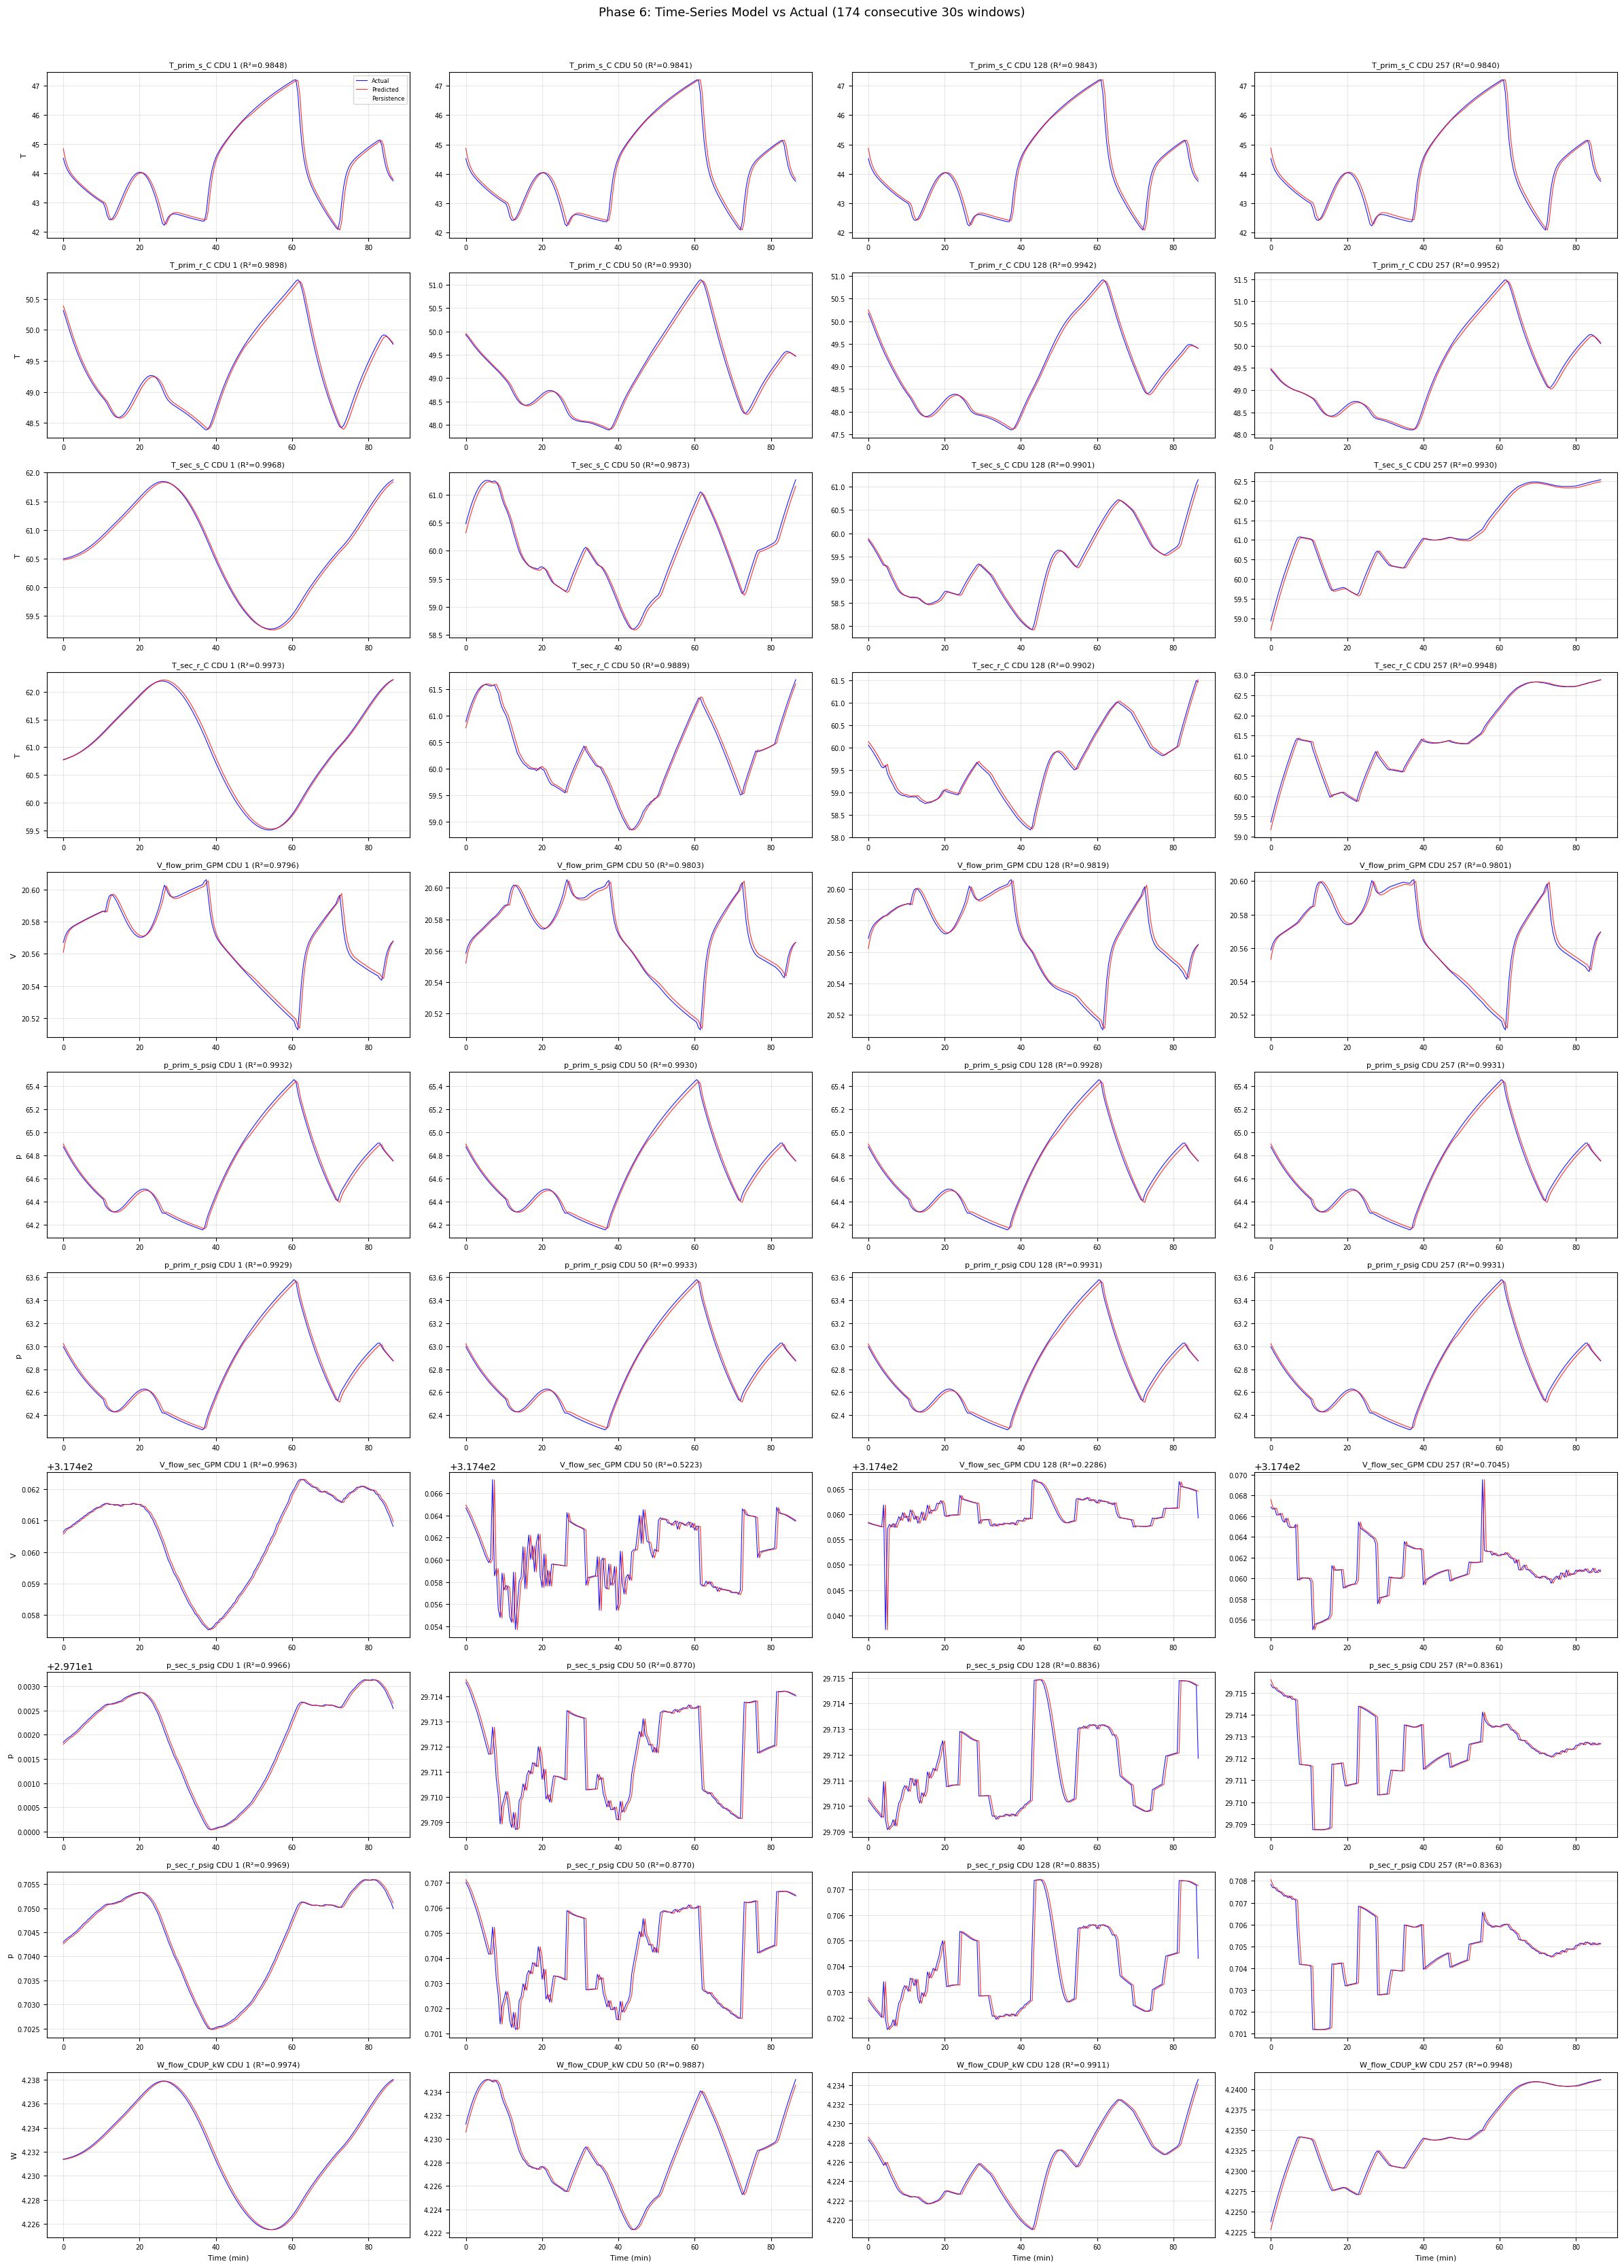

In [ ]:
#  Time-Series Predictions — Chain consecutive prediction windows

def plot_timeseries_predictions(predictions_dict, column_info, config,
                                 n_cdus=4, n_samples_show=200):
    """Chain consecutive 30-sec prediction windows into a continuous time-series."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_dyn = predictions_dict['last_dynamic']
    dynamic_cols = column_info['dynamic_cols']

    output_types_list = config.ALL_DYNAMIC_OUTPUTS
    n_types = len(output_types_list)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR

    N = min(n_samples_show, pred.shape[0])
    cdu_ids = [1, 50, 128, 257][:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.0 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(output_types_list):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]
            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in dynamic_cols:
                ax.set_visible(False); continue
            idx = dynamic_cols.index(col_name)

            t_actual, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_actual.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_dyn[i, idx])

            t_min = np.array(t_actual) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id} (R²={r2:.4f})', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type.split('_')[0], fontsize=8)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'Phase 6: Time-Series Model vs Actual ({N} consecutive {K*dt}s windows)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('phase_6_vis/timeseries_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_predictions(predictions_dict, column_info, config)

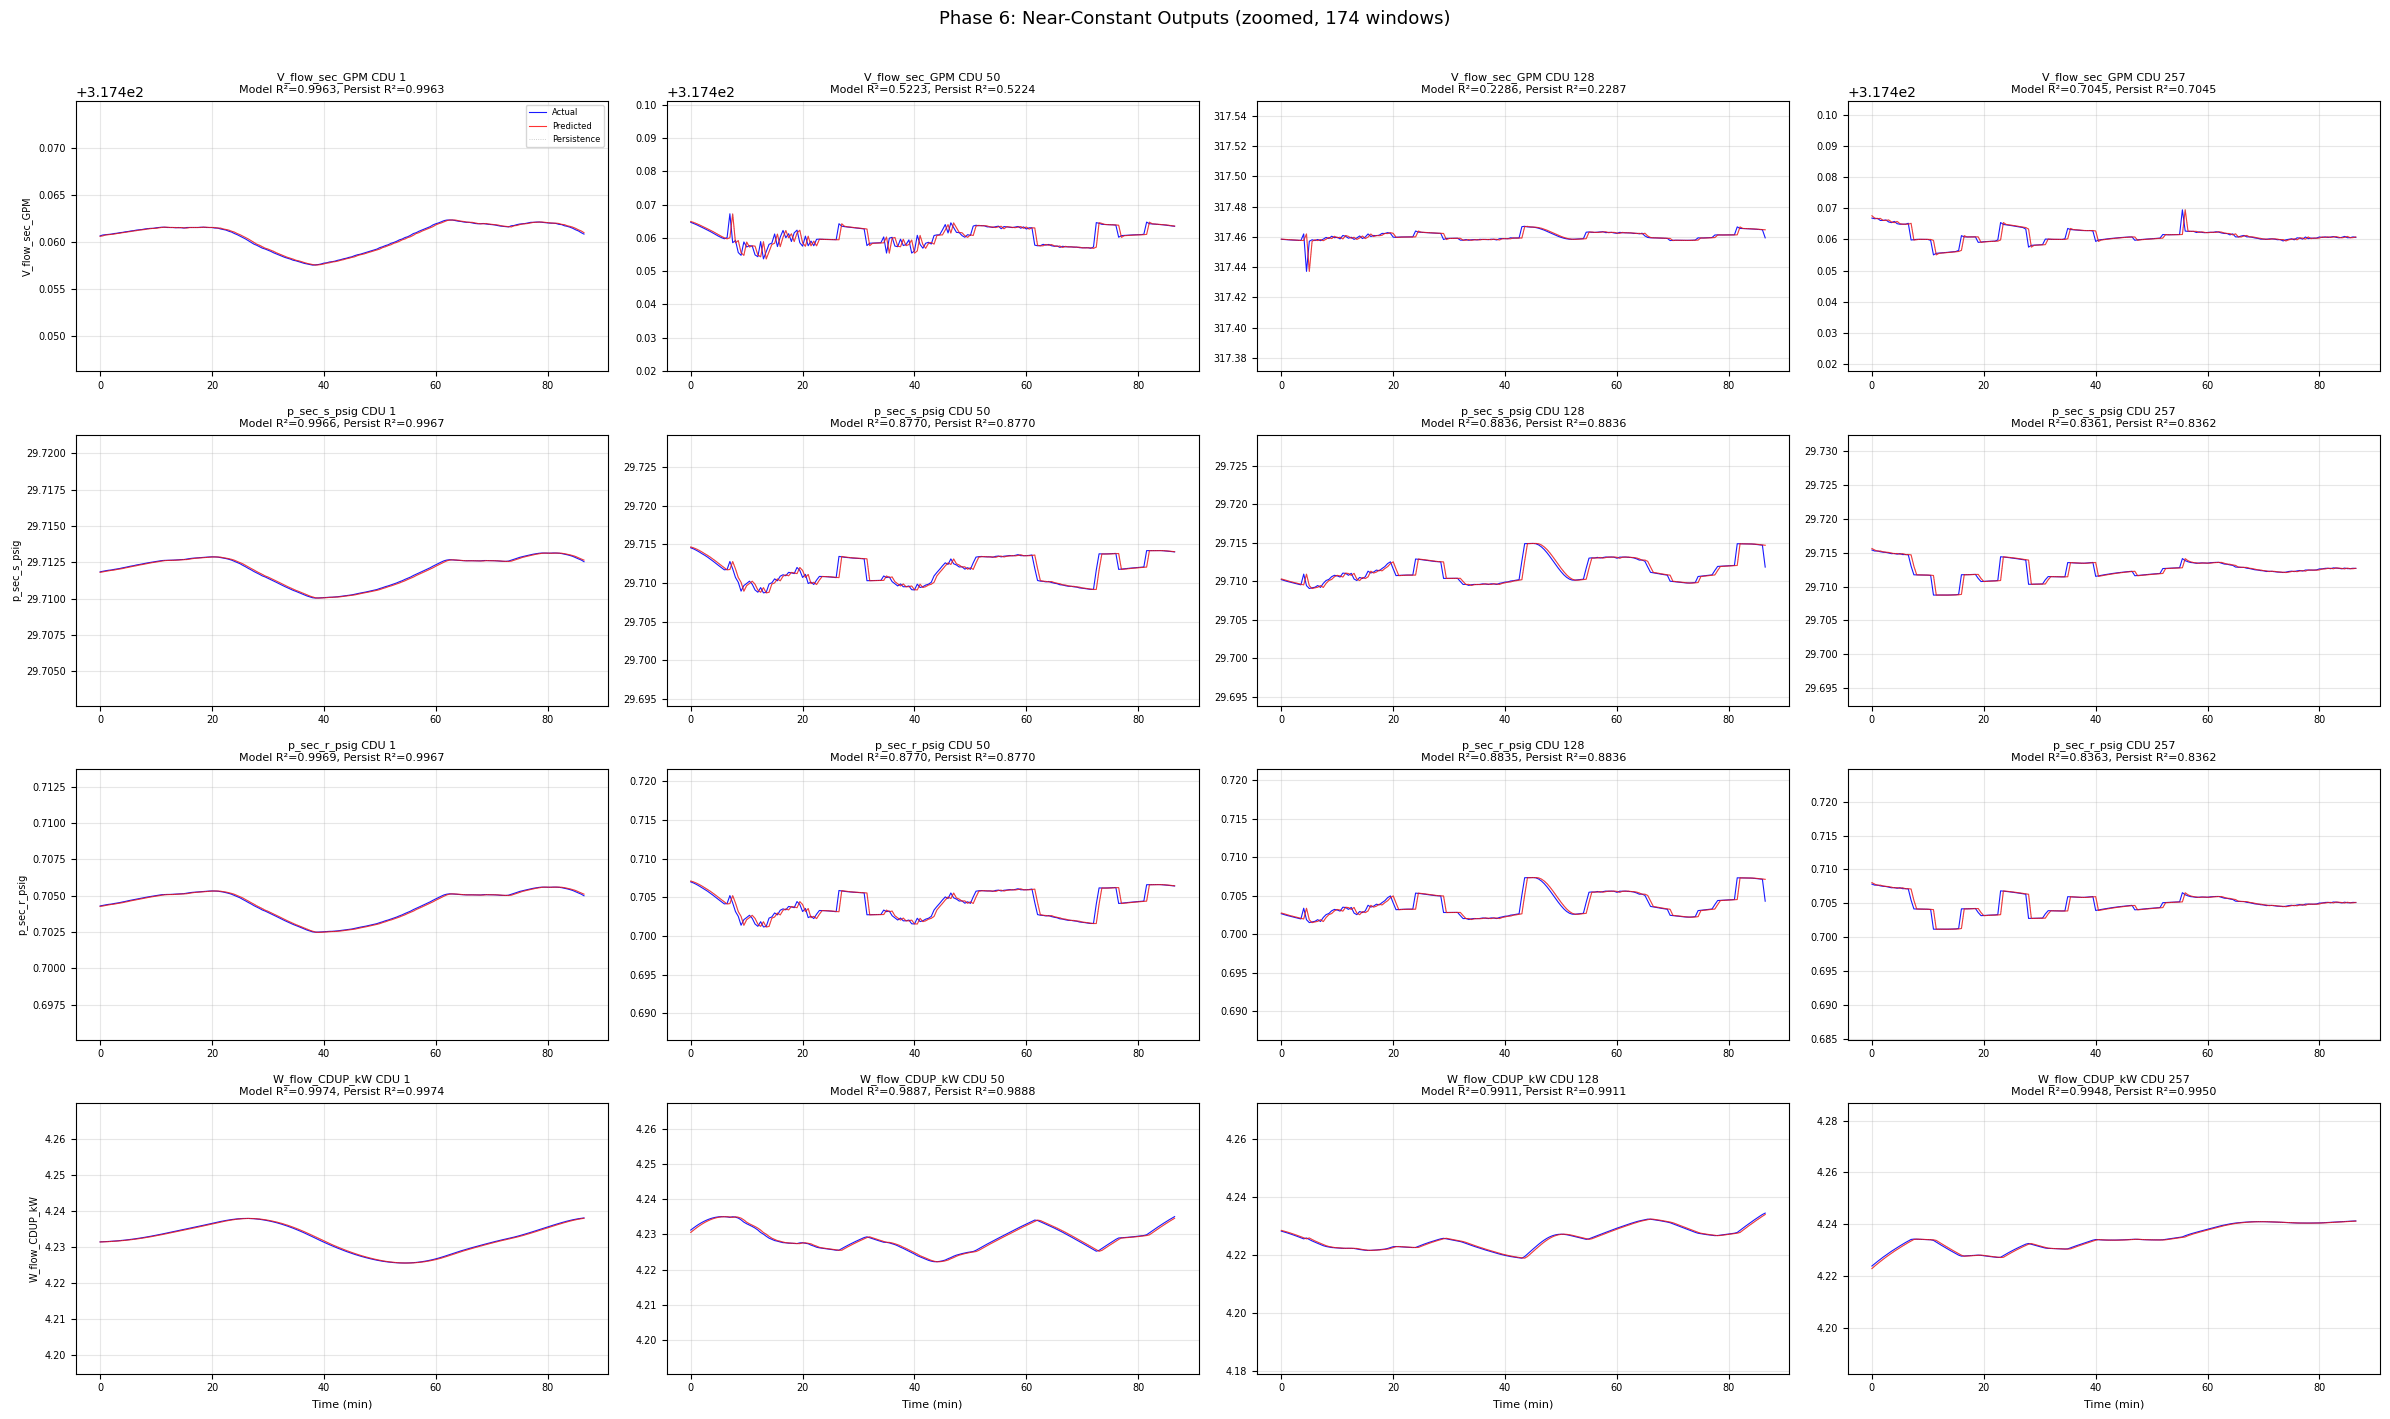

In [ ]:
#  Near-Constant Output Time-Series (Zoomed)

def plot_timeseries_nearconst(predictions_dict, column_info, config,
                               n_cdus=4, n_samples_show=200):
    """Dedicated time-series for near-constant outputs (G_Vs, G_ps, G_W)."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_dyn = predictions_dict['last_dynamic']
    dynamic_cols = column_info['dynamic_cols']

    nearconst_types = (config.FLOW_SEC_OUTPUTS +
                       config.PRESSURE_SEC_OUTPUTS + config.POWER_OUTPUTS)
    n_types = len(nearconst_types)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR
    N = min(n_samples_show, pred.shape[0])
    cdu_ids = [1, 50, 128, 257][:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.5 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(nearconst_types):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]
            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in dynamic_cols:
                ax.set_visible(False); continue
            idx = dynamic_cols.index(col_name)

            t_actual, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_actual.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_dyn[i, idx])

            t_min = np.array(t_actual) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Zoom to ±3× range for visibility
            y_mean = y_actual.mean()
            y_range = max(y_actual.max() - y_actual.min(), 1e-4)
            ax.set_ylim(y_mean - y_range * 3, y_mean + y_range * 3)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)
            ss_res_p = np.sum((y_actual - y_persist) ** 2)
            r2_p = 1 - ss_res_p / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id}\nModel R²={r2:.4f}, '
                         f'Persist R²={r2_p:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type, fontsize=7)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Phase 6: Near-Constant Outputs (zoomed, {N} windows)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('phase_6_vis/timeseries_nearconst.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_nearconst(predictions_dict, column_info, config)

## Physics Violation Analysis (Phase 6 Specific)

Evaluate physics constraint compliance on the **test set**. For each constraint, compute the violation rate and mean violation magnitude. Compare model predictions against ground truth to see if physics-informed training improved physical consistency.

In [ ]:
#  Physics Violation Analysis on Test Set

@torch.no_grad()
def compute_test_physics_violations(model, loader, pred_to_physics, physics_calc, device,
                                     max_batches=50):
    """
    Run physics violation analysis on test set for both model predictions and ground truth.
    Returns per-constraint violation rates and magnitudes for comparison.
    """
    model.eval()
    
    # Accumulators for model predictions and ground truth
    model_violations = {}   # constraint_name → list of (violation_magnitude, violated_bool)
    truth_violations = {}
    
    n_batches = 0
    for batch in tqdm(loader, desc="Physics violation analysis", leave=False):
        if n_batches >= max_batches:
            break
        n_batches += 1
        
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)
        last_dynamic = batch['last_dynamic'].to(device, non_blocking=True)
        raw_inputs_last = batch['raw_inputs_last'].to(device, non_blocking=True)
        y_delta = batch['y_delta'].to(device, non_blocking=True)
        
        # Model predictions
        output = model(u_hist, y_hist)
        pred_delta = output['predictions']  # (B, K, n_dynamic)
        
        # Convert to physical quantities
        try:
            phys_model = pred_to_physics(pred_delta, last_dynamic, raw_inputs_last)
            phys_truth = pred_to_physics(y_delta, last_dynamic, raw_inputs_last)
        except Exception as e:
            print(f"  Conversion error: {e}")
            continue
        
        # Compute physics losses for both
        try:
            train_losses_m, monitor_m = physics_calc(phys_model)
            train_losses_t, monitor_t = physics_calc(phys_truth)
        except Exception as e:
            print(f"  Physics calc error: {e}")
            continue
        
        # Accumulate training losses (Tier 1+2)
        for name, val in train_losses_m.items():
            v = val.item() if torch.is_tensor(val) else val
            if name not in model_violations:
                model_violations[name] = []
            model_violations[name].append(v)
        
        for name, val in train_losses_t.items():
            v = val.item() if torch.is_tensor(val) else val
            if name not in truth_violations:
                truth_violations[name] = []
            truth_violations[name].append(v)
        
        # Accumulate monitoring losses (Tier 3)
        for name, val in monitor_m.items():
            if name not in model_violations:
                model_violations[name] = []
            model_violations[name].append(val)
        
        for name, val in monitor_t.items():
            if name not in truth_violations:
                truth_violations[name] = []
            truth_violations[name].append(val)
    
    return model_violations, truth_violations


print("Computing physics violations on test set...")
model_violations, truth_violations = compute_test_physics_violations(
    model, test_loader, pred_to_physics, physics_loss_calc, DEVICE, max_batches=50
)

# Summary table
print(f"\n{'='*80}")
print("PHYSICS VIOLATION ANALYSIS — Test Set")
print(f"{'='*80}")
print(f"\n{'Constraint':<35} {'Model Mean':>12} {'Truth Mean':>12} {'Ratio':>8} {'Tier':>6}")
print("-" * 80)

constraint_summary = []
for name in sorted(set(list(model_violations.keys()) + list(truth_violations.keys()))):
    m_vals = model_violations.get(name, [0])
    t_vals = truth_violations.get(name, [0])
    m_mean = np.mean(m_vals)
    t_mean = np.mean(t_vals)
    ratio = m_mean / (t_mean + 1e-10) if t_mean > 1e-10 else (0.0 if m_mean < 1e-10 else float('inf'))
    
    # Determine tier
    tier = 'T3'
    for t1_name in ['temp_ordering', 'hx_feasibility', 'pressure_drop_direction', 'pue_bounds', 'carnot_limit']:
        if t1_name in name:
            tier = 'T1'
            break
    for t2_name in ['energy_conservation', 'approach_temp', 'wet_bulb', 'temperature_bounds',
                     'pressure_bounds', 'cop_bounds']:
        if t2_name in name:
            tier = 'T2'
            break
    
    print(f"  {name:<33} {m_mean:>12.6f} {t_mean:>12.6f} {ratio:>8.2f} {tier:>6}")
    constraint_summary.append({
        'constraint': name, 'model_mean': m_mean, 'truth_mean': t_mean,
        'ratio': ratio, 'tier': tier
    })

constraint_df = pd.DataFrame(constraint_summary)
print(f"\nNote: Ratio < 1.0 means model has FEWER violations than ground truth.")
print(f"      Ratio > 1.0 means model has MORE violations.")

Computing physics violations on test set...


Physics violation analysis:   0%|          | 0/3 [00:00<?, ?it/s]

  Physics calc error: 'PhysicsLossCalculator' object is not callable
  Physics calc error: 'PhysicsLossCalculator' object is not callable
  Physics calc error: 'PhysicsLossCalculator' object is not callable

PHYSICS VIOLATION ANALYSIS — Test Set

Constraint                            Model Mean   Truth Mean    Ratio   Tier
--------------------------------------------------------------------------------

Note: Ratio < 1.0 means model has FEWER violations than ground truth.
      Ratio > 1.0 means model has MORE violations.


In [ ]:
#  Physics Violation Visualization

if len(constraint_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    
    # (a) Model vs Truth violation magnitude (bar chart)
    ax = axes[0]
    n = len(constraint_df)
    x = np.arange(n)
    width = 0.35
    ax.barh(x - width/2, constraint_df['model_mean'], width, label='Model', 
            color='steelblue', alpha=0.8)
    ax.barh(x + width/2, constraint_df['truth_mean'], width, label='Ground Truth',
            color='lightcoral', alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(constraint_df['constraint'], fontsize=7)
    ax.set_xlabel('Mean Violation Magnitude')
    ax.set_title('Physics Violations: Model vs Ground Truth')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    
    # (b) Violation Ratio (model/truth) - < 1 is improvement
    ax = axes[1]
    ratios = constraint_df['ratio'].values
    colors_ratio = ['green' if r <= 1 else 'red' for r in ratios]
    ax.barh(x, ratios, color=colors_ratio, alpha=0.8, edgecolor='black')
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Equal')
    ax.set_yticks(x)
    ax.set_yticklabels(constraint_df['constraint'], fontsize=7)
    ax.set_xlabel('Ratio (Model / Truth)')
    ax.set_title('Violation Ratio (<1 = Model Better)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    
    # (c) By Tier breakdown
    ax = axes[2]
    for tier, color in [('T1', 'red'), ('T2', 'orange'), ('T3', 'gray')]:
        tier_data = constraint_df[constraint_df['tier'] == tier]
        if len(tier_data) > 0:
            ax.scatter(tier_data['truth_mean'], tier_data['model_mean'],
                      s=100, color=color, alpha=0.7, edgecolors='black',
                      label=f'Tier {tier[-1]} ({len(tier_data)})')
    
    all_vals = list(constraint_df['model_mean']) + list(constraint_df['truth_mean'])
    max_val = max(all_vals) if all_vals else 1.0
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y=x (equal)')
    ax.set_xlabel('Ground Truth Violation')
    ax.set_ylabel('Model Violation')
    ax.set_title('Model vs Truth Violations by Tier')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Phase 6: Physics Constraint Compliance Analysis', fontsize=14)
    plt.tight_layout()
    plt.savefig('phase_6_vis/physics_violations.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No constraint data available for visualization.")

No constraint data available for visualization.


## Save Results

Save model checkpoint, metrics, training history (all 3 phases), physics violation analysis, and normalizer states for reproducibility and cross-phase comparison.

In [ ]:
#  Save Results

import json

save_dir = 'saved_models/phase6_physics_informed'
os.makedirs(save_dir, exist_ok=True)

# 1. Model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': {
        'HISTORY_SECONDS': config.HISTORY_SECONDS,
        'SUBSAMPLE_FACTOR': config.SUBSAMPLE_FACTOR,
        'PREDICTION_STEPS': config.PREDICTION_STEPS,
        'BRANCH_HIDDEN': config.BRANCH_HIDDEN,
        'TBRANCH_HIDDEN': config.TBRANCH_HIDDEN,
        'LSTM_LAYERS': config.LSTM_LAYERS,
        'N_FOURIER_FREQ': config.N_FOURIER_FREQ,
        'TRUNK_HIDDEN': config.TRUNK_HIDDEN,
        'N_BASIS': config.N_BASIS,
        'DECODER_HIDDEN': config.DECODER_HIDDEN,
        'DECODER_HIDDEN_SMALL': config.DECODER_HIDDEN_SMALL,
        'PHASE1_EPOCHS': config.PHASE1_EPOCHS,
        'PHASE2_EPOCHS': config.PHASE2_EPOCHS,
        'PHASE3_EPOCHS': config.PHASE3_EPOCHS,
        'PHYSICS_WEIGHT_MAX': config.PHYSICS_WEIGHT_MAX,
        'PHYSICS_RAMP_EPOCHS': config.PHYSICS_RAMP_EPOCHS,
        'LEARNING_RATE': config.LEARNING_RATE,
        'DROPOUT': config.DROPOUT,
    },
    'column_info': column_info,
    'total_params': total_params,
    'n_inputs': n_inputs,
    'n_dynamic': n_dynamic,
}
torch.save(checkpoint, os.path.join(save_dir, 'phase6_model.pt'))
print(f"Model checkpoint saved to {save_dir}/phase6_model.pt")

# 2. Training history (all 3 phases)
history = {
    'phase1': phase1_history,
    'phase2': phase2_history,
    'phase3': phase3_history,
    'phase1_epochs': phase1_epochs,
    'phase2_epochs': phase2_epochs,
    'phase3_epochs': phase3_epochs,
    'phase1_time': phase1_time,
    'phase2_time': phase2_time,
    'phase3_time': phase3_time,
    'total_train_time': total_train_time,
}
with open(os.path.join(save_dir, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2, default=str)
print("Training history saved (3 phases)")

# 3. Metrics
metrics_df.to_csv(os.path.join(save_dir, 'phase6_metrics.csv'), index=False)
print(f"Metrics saved: {len(metrics_df)} outputs")

# 4. Physics violation analysis
if len(constraint_df) > 0:
    constraint_df.to_csv(os.path.join(save_dir, 'physics_violations.csv'), index=False)
    print(f"Physics violations saved: {len(constraint_df)} constraints")

# 5. Normalizer states
normalizer_state = {}
with open(os.path.join(save_dir, 'normalizer_states.json'), 'w') as f:
    json.dump(normalizer_state, f, indent=2)
print("Normalizer states saved")

# 6. Predictions (compressed)
np.savez_compressed(
    os.path.join(save_dir, 'phase6_predictions.npz'),
    pred_absolute=predictions_dict['pred_absolute'],
    target_absolute=predictions_dict['target_absolute'],
    pred_normalized=predictions_dict['pred_normalized'],
    target_normalized=predictions_dict['target_normalized'],
    last_dynamic=predictions_dict['last_dynamic'],
)
print("Predictions saved (compressed)")
print(f"\nAll results saved to {save_dir}/")

Model checkpoint saved to saved_models/phase6_physics_informed/phase6_model.pt
Training history saved (3 phases)
Metrics saved: 2827 outputs
Normalizer states saved
Predictions saved (compressed)

All results saved to saved_models/phase6_physics_informed/


In [ ]:
#  Final Summary

print("=" * 80)
print("PHASE 6: PHYSICS‑INFORMED FEDERATED DEEPM&MNET — FINAL SUMMARY")
print("=" * 80)

print("\n--- Architecture ---")
print(f"  Shared Encoder: Branch LSTM ({config.BRANCH_HIDDEN}h, {config.LSTM_LAYERS}L) "
      f"+ TBranch LSTM ({config.TBRANCH_HIDDEN}h, {config.LSTM_LAYERS}L) "
      f"+ Fourier Trunk ({config.N_FOURIER_FREQ} freq, {config.TRUNK_HIDDEN}h)")
print(f"  Fusion: Hadamard product z[k] = b ⊙ tb ⊙ T[k]")
print(f"  Decoder Heads:")
for name in ALL_HEAD_NAMES:
    if name in column_info['head_groups']:
        group_info = column_info['head_groups'][name]
        n_out = len(group_info['cols'])
        head_type = group_info['type']
        group_metrics = metrics_df[metrics_df['Group'] == name]
        mean_r2 = group_metrics['R2'].mean() if len(group_metrics) > 0 else 0.0
        print(f"    {name}: {head_type} head, {n_out} outputs, mean R²={mean_r2:.4f}")
print(f"  Total Parameters: {total_params:,}")

print(f"\n--- Physics Integration ---")
print(f"  Tier 1 (Hard) Constraints: temp ordering, HX feasibility, pressure drop, PUE, Carnot")
print(f"  Tier 2 (Soft) Constraints: energy conservation, approach temps, wet-bulb, "
      f"T/P bounds, COP")
print(f"  Tier 3 (Monitor only): pump power, monotonicity — NOT in training loss")
print(f"  Physics Weight Max (λ): {config.PHYSICS_WEIGHT_MAX}")
print(f"  Ramp Schedule: 0 → {config.PHYSICS_WEIGHT_MAX} over {config.PHYSICS_RAMP_EPOCHS} epochs in Phase 2")

print(f"\n--- Training (3-Phase Curriculum) ---")
print(f"  Phase 1 (Data-Only Round-Robin): {phase1_epochs} epochs, {phase1_time:.1f}s")
print(f"  Phase 2 (Physics Ramp):          {phase2_epochs} epochs, {phase2_time:.1f}s")
print(f"  Phase 3 (Full Physics Joint):    {phase3_epochs} epochs, {phase3_time:.1f}s")
print(f"  Total Training Time: {total_train_time:.1f}s ({total_train_time/60:.1f} min)")
print(f"  Total Epochs: {total_epochs}")

print(f"\n--- Data ---")
print(f"  Dataset: systematic_fmu_output_11hrs.parquet")
print(f"  Inputs: {n_inputs} features, Outputs: {n_dynamic} dynamic outputs")
print(f"  History: {config.HISTORY_SECONDS}s ({config.HISTORY_SECONDS // config.SUBSAMPLE_FACTOR} steps)")
print(f"  Prediction: K={config.PREDICTION_STEPS} step ({config.PREDICTION_STEPS * config.SUBSAMPLE_FACTOR}s)")

print(f"\n--- Overall Performance ---")
print(f"  Mean R²: {metrics_df['R2'].mean():.4f} ± {metrics_df['R2'].std():.4f}")
print(f"  Median R²: {metrics_df['R2'].median():.4f}")
print(f"  Mean RMSE: {metrics_df['RMSE'].mean():.6f}")
print(f"  Mean MAE: {metrics_df['MAE'].mean():.6f}")
print(f"  Mean Correlation: {metrics_df['Correlation'].mean():.4f}")
print(f"  Mean Variance Ratio: {metrics_df['Variance_Ratio'].mean():.4f}")

print(f"\n--- Primary vs Secondary Loop ---")
primary = metrics_df[metrics_df['Loop'] == 'primary']
secondary = metrics_df[metrics_df['Loop'] == 'secondary']
print(f"  Primary Loop: {len(primary)} outputs, mean R²={primary['R2'].mean():.4f}")
print(f"  Secondary Loop: {len(secondary)} outputs, mean R²={secondary['R2'].mean():.4f}")
print(f"  Primary beats persistence: {primary['Beats_Persistence'].mean()*100:.1f}%")
print(f"  Secondary beats persistence: {secondary['Beats_Persistence'].mean()*100:.1f}%")

print(f"\n--- Physics Compliance (Test Set) ---")
if len(constraint_df) > 0:
    for _, row in constraint_df.iterrows():
        marker = '✓' if row['ratio'] <= 1.0 else '✗'
        print(f"  {marker} {row['constraint']}: model={row['model_mean']:.6f}, "
              f"truth={row['truth_mean']:.6f}, ratio={row['ratio']:.2f}")

print(f"\n--- R² Distribution ---")
for threshold in [0.99, 0.95, 0.90, 0.80, 0.50]:
    count = (metrics_df['R2'] >= threshold).sum()
    pct = count / len(metrics_df) * 100
    print(f"  R² ≥ {threshold}: {count}/{len(metrics_df)} ({pct:.1f}%)")

print(f"\n--- Computational Performance ---")
print(f"  Inference Time: {inference_time:.2f}s for {n_test_samples} samples")
print(f"  Throughput: {n_test_samples/inference_time:.1f} samples/sec")
print(f"  Device: {DEVICE}")

print("\n" + "=" * 80)
print("Phase 6 notebook complete.")
print("=" * 80)

PHASE 6: PHYSICS‑INFORMED FEDERATED DEEPM&MNET — FINAL SUMMARY

--- Architecture ---
  Shared Encoder: Branch LSTM (128h, 2L) + TBranch LSTM (128h, 2L) + Fourier Trunk (8 freq, 64h)
  Fusion: Hadamard product z[k] = b ⊙ tb ⊙ T[k]
  Decoder Heads:
    G_T: standard head, 1028 outputs, mean R²=0.9921
    G_V: standard head, 257 outputs, mean R²=0.9810
    G_p: standard head, 514 outputs, mean R²=0.9930
    G_Vs: skip head, 257 outputs, mean R²=0.8124
    G_ps: skip head, 514 outputs, mean R²=0.9254
    G_W: skip head, 257 outputs, mean R²=0.9958
  Total Parameters: 3,113,756

--- Physics Integration ---
  Tier 1 (Hard) Constraints: temp ordering, HX feasibility, pressure drop, PUE, Carnot
  Tier 2 (Soft) Constraints: energy conservation, approach temps, wet-bulb, T/P bounds, COP
  Tier 3 (Monitor only): pump power, monotonicity — NOT in training loss
  Physics Weight Max (λ): 0.1
  Ramp Schedule: 0 → 0.1 over 30 epochs in Phase 2

--- Training (3-Phase Curriculum) ---
  Phase 1 (Data-Onl